Documentation: https://keypoint-moseq.readthedocs.io/en/latest/modeling.html

In [25]:
import os
os.environ["OMP_NUM_THREADS"] = "36"
os.environ["MKL_NUM_THREADS"] = "36"
os.environ["OPENBLAS_NUM_THREADS"] = "36"
os.environ["NUMEXPR_NUM_THREADS"] = "36"
os.environ["XLA_FLAGS"] = (
    "--xla_cpu_multi_thread_eigen=true "
)


import keypoint_moseq as kpms
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import re

print("XLA_FLAGS:", os.environ.get("XLA_FLAGS"))
print("OMP_NUM_THREADS:", os.environ.get("OMP_NUM_THREADS"))

MULTI_ANIMAL = False

XLA_FLAGS: --xla_cpu_multi_thread_eigen=true 
OMP_NUM_THREADS: 36


## Setting up the data. Videography data from the final day of the adaptive mice (Agg and NonAgg) and from Day 05 (the last day of the first week) of the maladaptive mice were used to tune the hyperparameters and train the KeypointMoSeq model

In [26]:
dlc_config_file = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingAggression_trainingSessions_topView-MiguelRocha-2026-02-03\config.yaml"

if MULTI_ANIMAL:
    kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS_multiAnimal"
else: 
    kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_KPMS_Resident"

kpms.setup_project(kpmoseq_dir, deeplabcut_config=dlc_config_file, overwrite = False)

config = lambda: kpms.load_config(kpmoseq_dir)

The directory `C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\t
rainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessi
ons_topView_KPMS_Resident` already exists. Use `overwrite=True` or
pick a different name


In [27]:
kpms.setup_project(kpmoseq_dir, deeplabcut_config=dlc_config_file, overwrite = False)

config = lambda: kpms.load_config(kpmoseq_dir)

The directory `C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\t
rainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessi
ons_topView_KPMS_Resident` already exists. Use `overwrite=True` or
pick a different name


In [28]:
dlc_videos_path = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_DLC_multiAnimal")

pcutoff = 0.8
dlc_folders_dataset = [str(f) for f in dlc_videos_path.rglob(rf"*{pcutoff}_skeleton\*snapshot_best-100_sk.h5")]
#np.save(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\filesUsed_forTraining", dlc_folders)

dlc_folders_train = list(np.load(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\filesUsed_forTraining.npy"))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\trainingSessions_topView_KPMS\\filesUsed_forTraining.npy'

In [ ]:
if MULTI_ANIMAL:
    exclude = ["single"]
else:
    exclude = ["Intruder","single"]

#raw_coordinates, raw_confidences, _ = kpms.load_keypoints(dlc_folders_train, "deeplabcut", exclude_individuals=exclude)

In [ ]:
# For some reason, bodyparts returned from kpms.load_keypoints is of type "set", not "list". This means that bodypart label's order is not aligned anymore with the other variables 

with open(dlc_config_file, "r") as f:
        dlcConfig = yaml.safe_load(f)

bodyparts = dlcConfig["multianimalbodyparts"]

In [ ]:
for key, value in raw_coordinates.items():
    kpms.check_nan_proportions({key: value}, list(bodyparts), breakdown=True)

Styler.applymap has been deprecated. Use Styler.map instead.

,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse975826_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.462980,0.024293,0.025656,0.055507,0.005915,0.005528,0.010172,0.036866,0.065061,0.110132


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse975827_Day17_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.527629,0.007510,0.006738,0.032212,0.000177,0.000080,0.000273,0.001544,0.005838,0.018494


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse975830_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.513986,0.006200,0.003901,0.035369,0.001295,0.000049,0.001878,0.004727,0.014989,0.032147


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse975833_Day19_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.445265,0.015426,0.008304,0.036032,0.001360,0.000534,0.003286,0.009663,0.022435,0.047476


...

,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse978528_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.637366,0.008936,0.008704,0.035745,0.001777,0.001329,0.002276,0.007275,0.013454,0.037605


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse1010832_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.730426,0.007510,0.006921,0.019128,0.001113,0.000998,0.001996,0.005792,0.013385,0.051248


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse1013590_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.602160,0.005940,0.004107,0.034165,0.001031,0.001325,0.001833,0.005760,0.010014,0.040759


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse1034805_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.613207,0.005488,0.005260,0.045485,0.001515,0.000668,0.001189,0.005146,0.008078,0.030877


,nose,rightEar,leftEar,neckBase,betNeckBaseAndMidPoint,midPoint,betMidPointAndTailBase,tailBase,tailMid,tailTip
mouse1034814_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk_Resident,0.734610,0.020878,0.025568,0.032425,0.001645,0.001287,0.002703,0.015667,0.038271,0.061315


In [ ]:
kpms.update_config(kpmoseq_dir, fps=50, outlier_scale_factor=6.0)

coordinates, confidences = kpms.outlier_removal(
    raw_coordinates,
    raw_confidences,
    kpmoseq_dir,
    overwrite=False,
    **config()
)

In [ ]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

In [ ]:
#%matplotlib widget
#kpms.noise_calibration(kpmoseq_dir, coordinates, confidences, **config())

## Extracting the number of components from videography data that explain >= 90% of the variance in behavioral syllables

>=90.0% of variance exlained by 5 components.


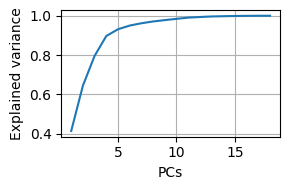

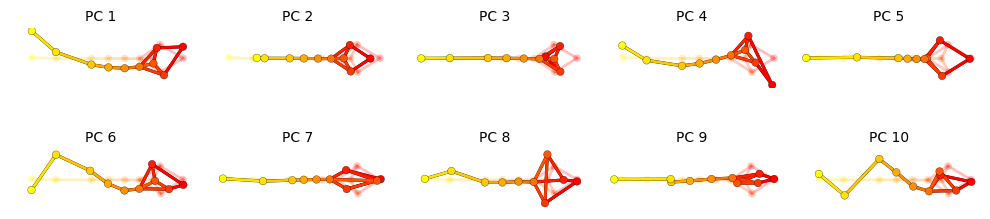

In [ ]:
plt.close("all")
%matplotlib inline
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, kpmoseq_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=kpmoseq_dir)
kpms.plot_pcs(pca, project_dir=kpmoseq_dir, **config())

In [ ]:
kpms.update_config(kpmoseq_dir, latent_dim=5) # >= 90.0% of the variance is explained by 6 components

In [ ]:
kpms.update_config(
    kpmoseq_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

## **Kappa scan**: Hyperparameter that that determines the rate of transitions between syllables. Higher values of kappa lead to longer syllables and smaller values lead to shorter syllables.

Fitting model with kappa=1000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000.0


 49%|█████████████████▏                 | 25/51 [07:24<07:20, 16.93s/it]

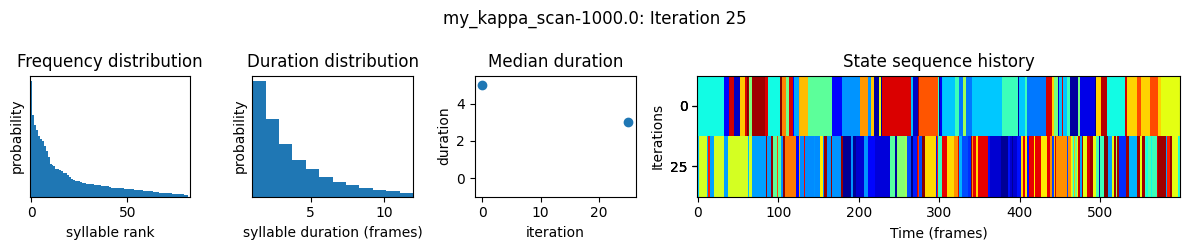

 98%|██████████████████████████████████▎| 50/51 [14:26<00:16, 16.82s/it]

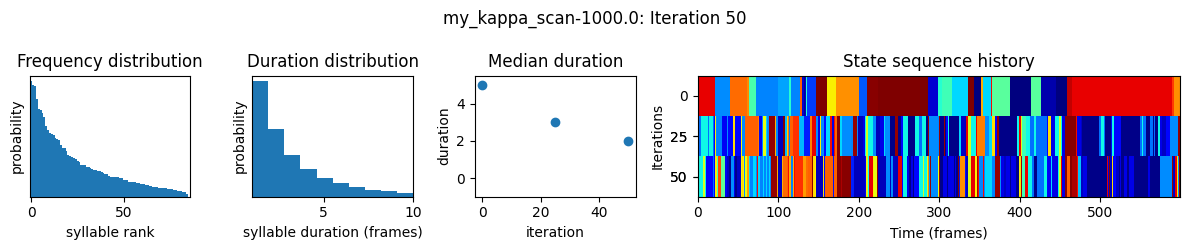

100%|███████████████████████████████████| 51/51 [14:45<00:00, 17.35s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000.0


 49%|██████████████▋               | 25/51 [1:26:18<1:29:55, 207.50s/it]

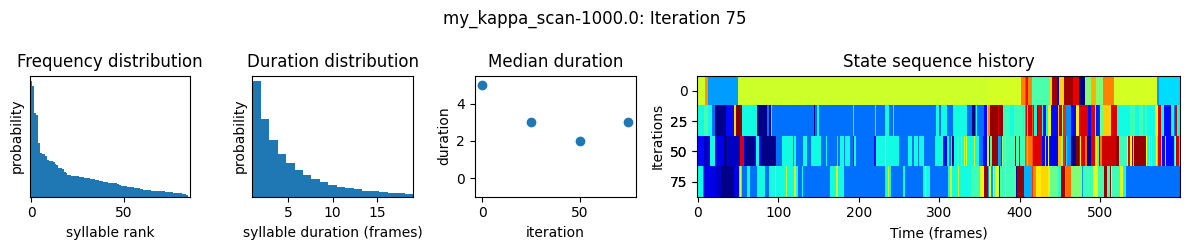

 98%|███████████████████████████████▎| 50/51 [2:52:26<03:26, 206.76s/it]

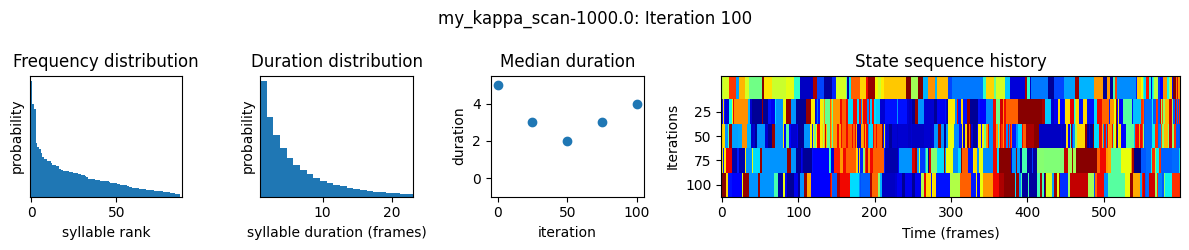

100%|████████████████████████████████| 51/51 [2:55:56<00:00, 206.99s/it]


Fitting model with kappa=10000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000.0


 49%|█████████████████▏                 | 25/51 [07:19<07:37, 17.58s/it]

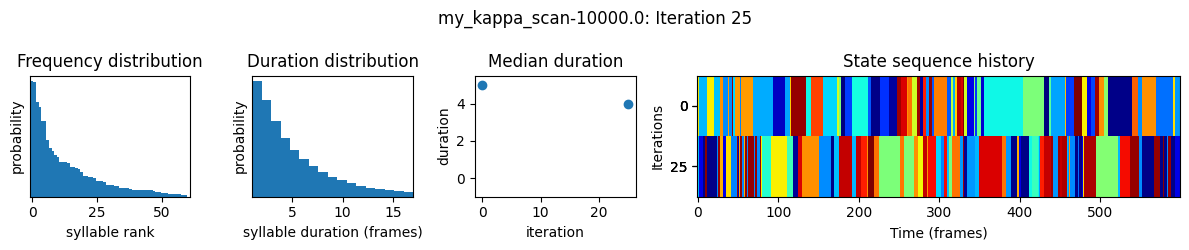

 98%|██████████████████████████████████▎| 50/51 [14:27<00:17, 17.05s/it]

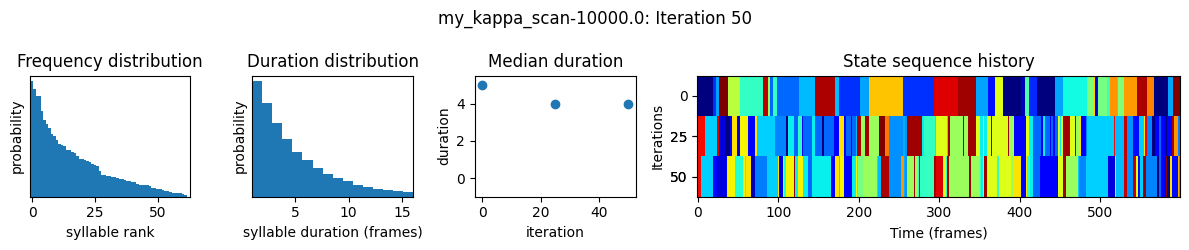

100%|███████████████████████████████████| 51/51 [14:45<00:00, 17.36s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000.0


 49%|██████████████▋               | 25/51 [1:26:16<1:29:54, 207.49s/it]

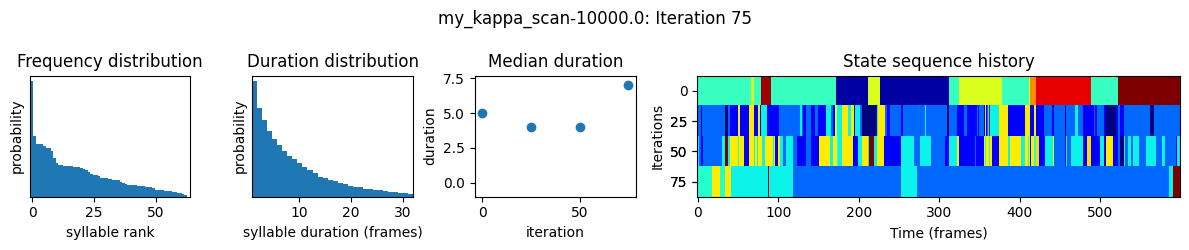

 98%|███████████████████████████████▎| 50/51 [2:52:37<03:26, 207.00s/it]

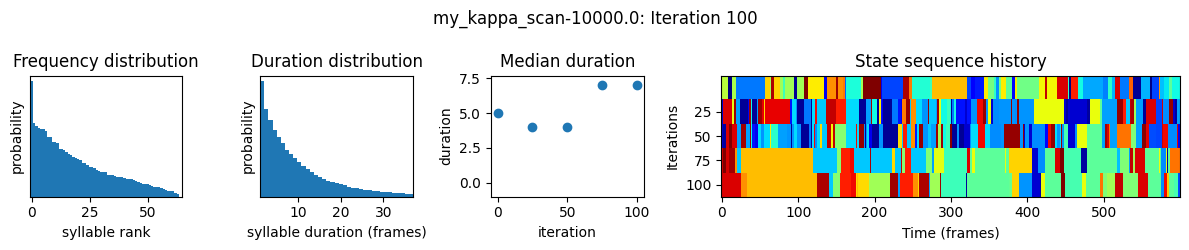

100%|████████████████████████████████| 51/51 [2:56:06<00:00, 207.18s/it]


Fitting model with kappa=100000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000.0


 49%|█████████████████▏                 | 25/51 [06:40<06:50, 15.79s/it]

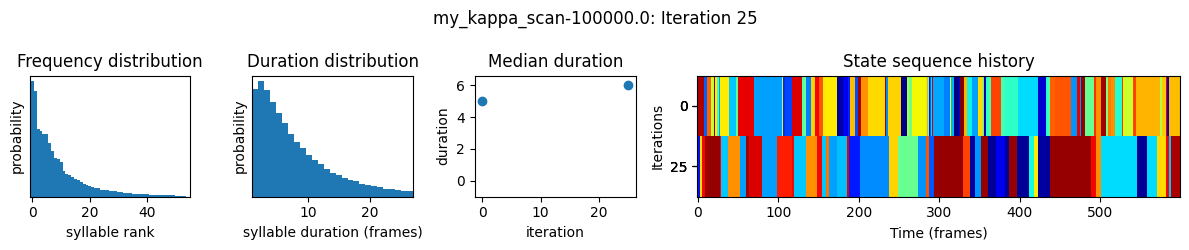

 98%|██████████████████████████████████▎| 50/51 [13:18<00:15, 15.90s/it]

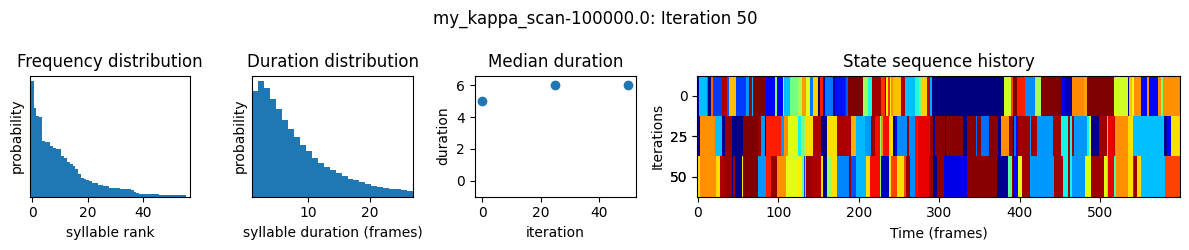

100%|███████████████████████████████████| 51/51 [13:36<00:00, 16.00s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000.0


 49%|██████████████▋               | 25/51 [1:25:15<1:29:49, 207.29s/it]

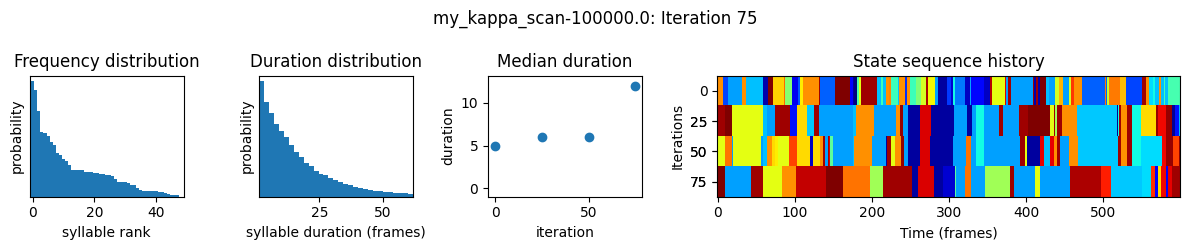

 98%|███████████████████████████████▎| 50/51 [2:50:04<03:25, 205.70s/it]

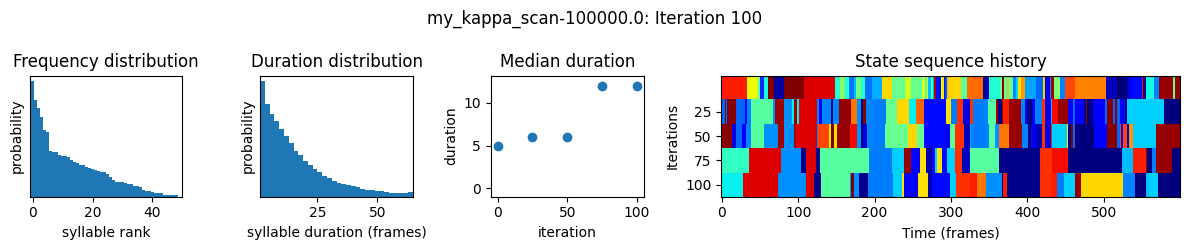

100%|████████████████████████████████| 51/51 [2:53:33<00:00, 204.18s/it]


Fitting model with kappa=1000000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000000.0


 49%|█████████████████▏                 | 25/51 [07:06<07:25, 17.14s/it]

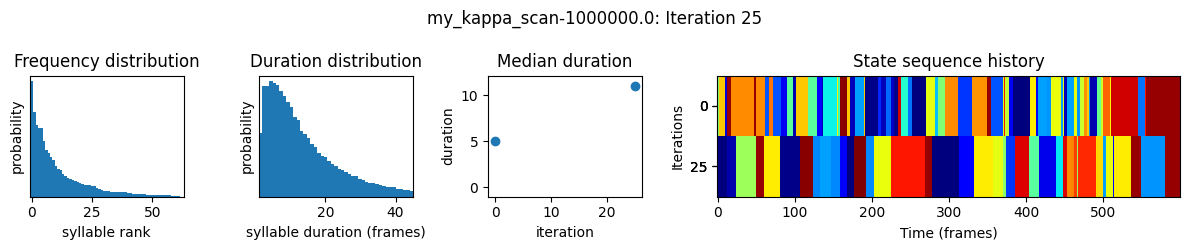

 98%|██████████████████████████████████▎| 50/51 [14:12<00:16, 16.96s/it]

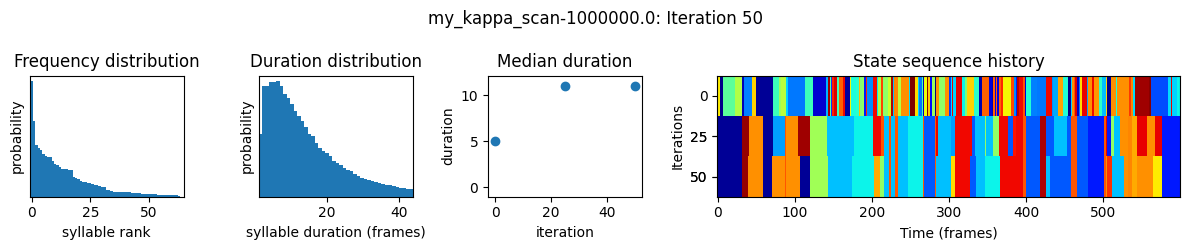

100%|███████████████████████████████████| 51/51 [14:31<00:00, 17.09s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
1000000.0


 49%|██████████████▋               | 25/51 [1:25:04<1:27:49, 202.66s/it]

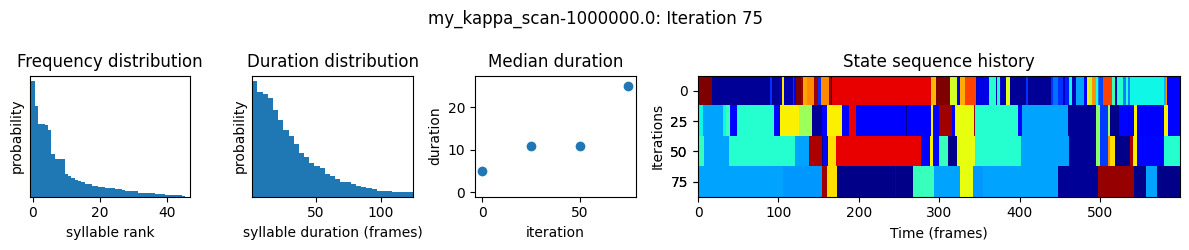

 98%|███████████████████████████████▎| 50/51 [2:50:38<03:23, 203.09s/it]

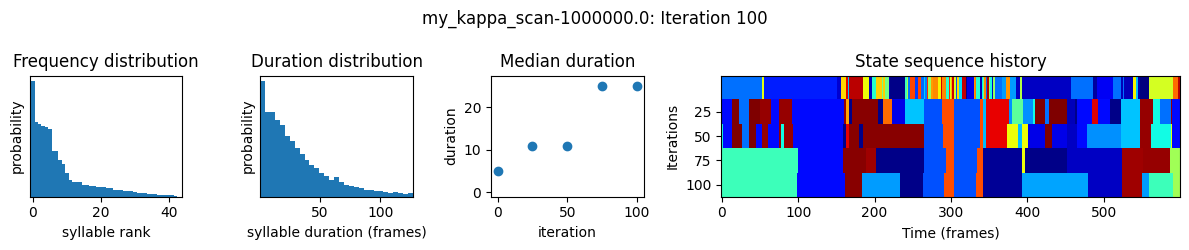

100%|████████████████████████████████| 51/51 [2:54:03<00:00, 204.77s/it]


Fitting model with kappa=10000000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000000.0


 49%|█████████████████▏                 | 25/51 [06:41<06:52, 15.85s/it]

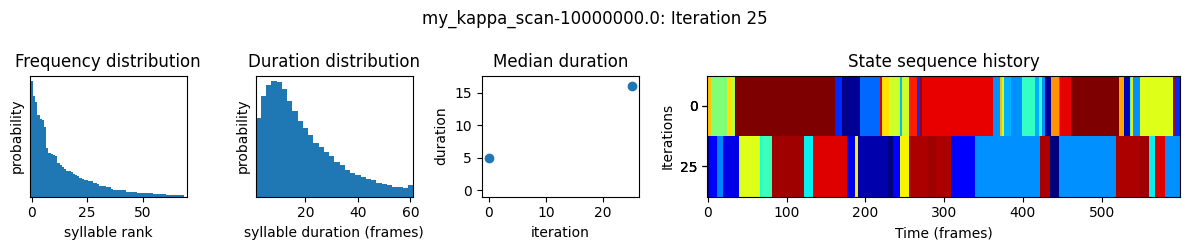

 98%|██████████████████████████████████▎| 50/51 [13:20<00:15, 15.92s/it]

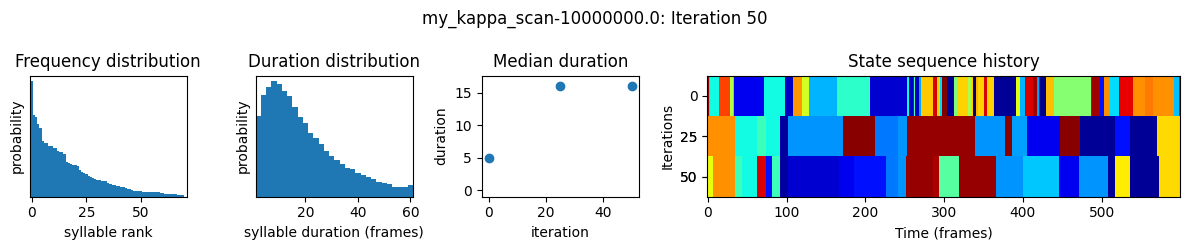

100%|███████████████████████████████████| 51/51 [13:37<00:00, 16.04s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
10000000.0


 49%|██████████████▋               | 25/51 [1:24:40<1:28:02, 203.19s/it]

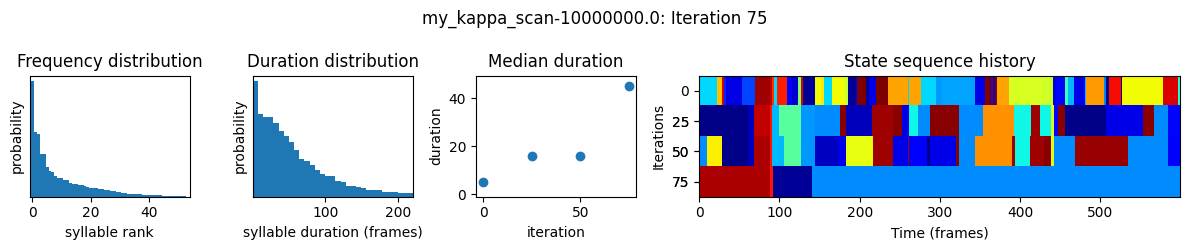

 98%|███████████████████████████████▎| 50/51 [2:50:18<03:24, 204.43s/it]

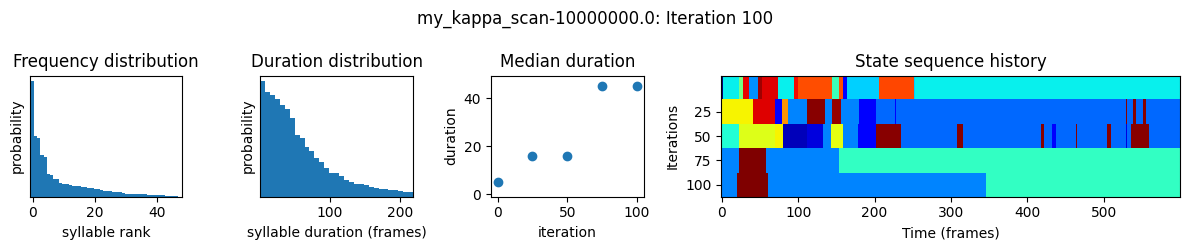

100%|████████████████████████████████| 51/51 [2:53:46<00:00, 204.44s/it]


Fitting model with kappa=100000000.0
Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000000.0


 49%|█████████████████▏                 | 25/51 [07:05<06:56, 16.04s/it]

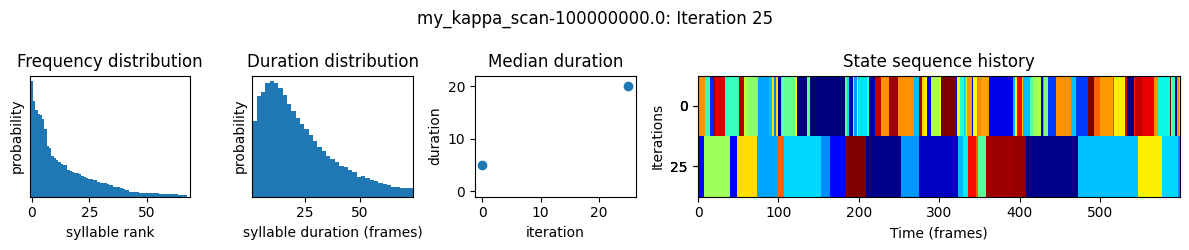

 98%|██████████████████████████████████▎| 50/51 [13:43<00:15, 15.85s/it]

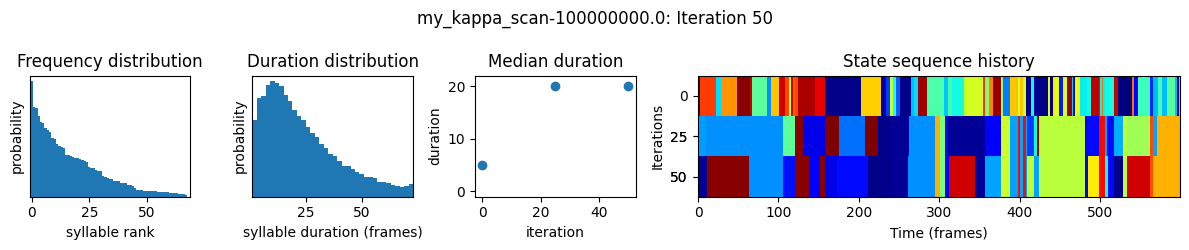

100%|███████████████████████████████████| 51/51 [14:00<00:00, 16.48s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS\my_kappa_scan-
100000000.0


 49%|██████████████▋               | 25/51 [1:23:16<1:17:35, 179.04s/it]

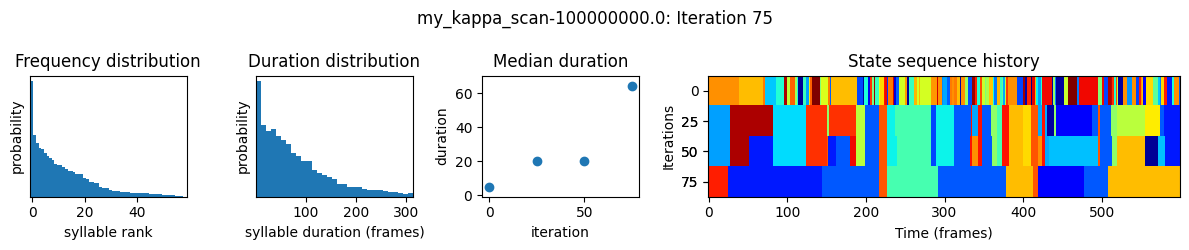

 98%|███████████████████████████████▎| 50/51 [2:29:38<02:36, 156.39s/it]

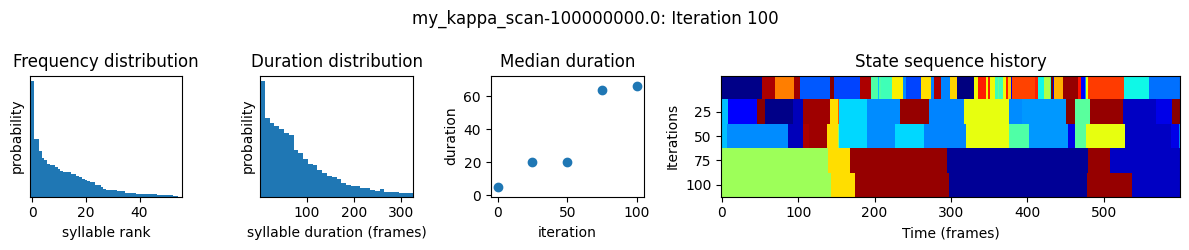

Loading checkpoints: 100%|██████████| 6/6 [00:01<00:00,  5.64it/s]


(<Figure size 800x250 with 2 Axes>, array([ 4.,  7., 12., 25., 45., 66.]))

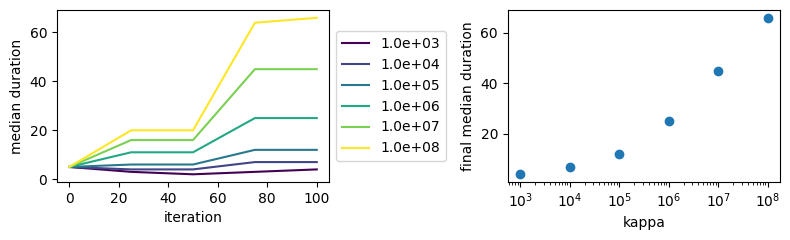

In [ ]:
'''
kappas = np.logspace(3,8,6)
decrease_kappa_factor = 10
num_ar_iters = 50
num_full_iters = 100

prefix = 'my_kappa_scan'

for kappa in kappas:
    print(f"Fitting model with kappa={kappa}")
    model_name = f'{prefix}-{kappa}'
    model = kpms.init_model(data, pca=pca, **config())

    # stage 1: fit the model with AR only
    model = kpms.update_hypparams(model, kappa=kappa)
    model = kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=True,
        num_iters=num_ar_iters,
        save_every_n_iters=25
    )[0];

    # stage 2: fit the full model
    model = kpms.update_hypparams(model, kappa=kappa/decrease_kappa_factor)
    kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=False,
        start_iter=num_ar_iters,
        num_iters=num_full_iters,
        save_every_n_iters=25
    );

kpms.plot_kappa_scan(kappas, kpmoseq_dir, prefix)

'''

### Loading a trained model and continue training from last checkpoint (iteration)

In [ ]:
'''
kappa = 1.0e5
model_name = "my_kappa_scan-100000.0"

model_to_fit, data, metadata, current_iter = kpms.load_checkpoint(
    kpmoseq_dir, model_name
)

# modify kappa to maintain the desired syllable time-scale
model_to_fit = kpms.update_hypparams(model_to_fit, kappa = kappa)


# run fitting for an additional 300 iters
model = kpms.fit_model(
    model_to_fit,
    data,
    metadata,
    kpmoseq_dir,
    f"fullModel_{kappa}",
    ar_only=False,
    start_iter=current_iter,
    num_iters=current_iter + 300,
)[0]

'''

### Training a new model with a pre selected kappa value 

Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS_multiAnimal\fu
llModel_1000000.0


 49%|█████████████████▏                 | 25/51 [09:30<09:51, 22.75s/it]

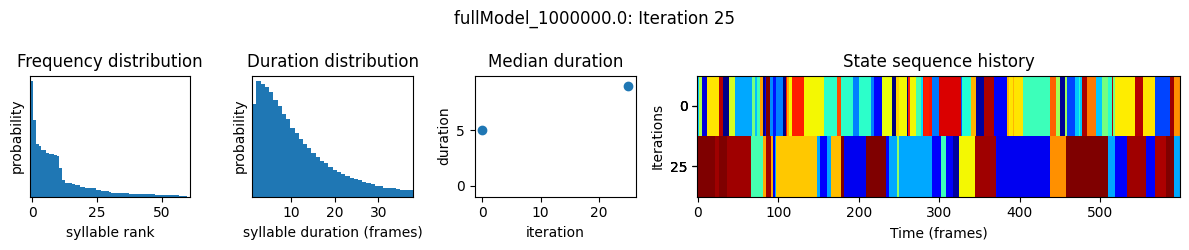

 98%|██████████████████████████████████▎| 50/51 [18:59<00:22, 22.54s/it]

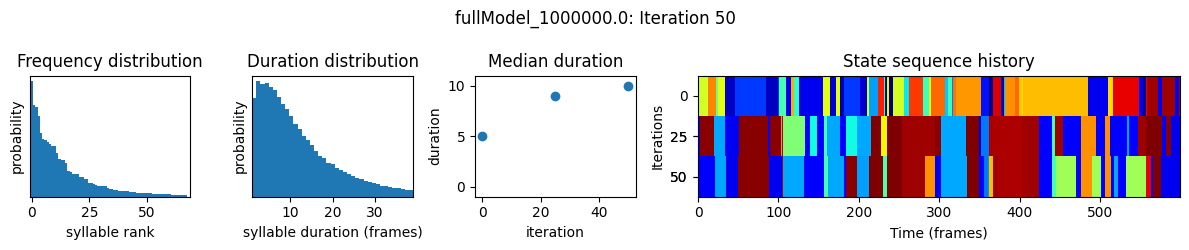

100%|███████████████████████████████████| 51/51 [19:24<00:00, 22.83s/it]


Outputs will be saved to C:\Users\stagk\OneDrive\Desktop\trainingAggre
ssion_MR\trainingSessions\trainingSessions_topView_KPMS_multiAnimal\fu
llModel_1000000.0


  8%|██▎                         | 25/301 [2:01:21<22:03:50, 287.79s/it]

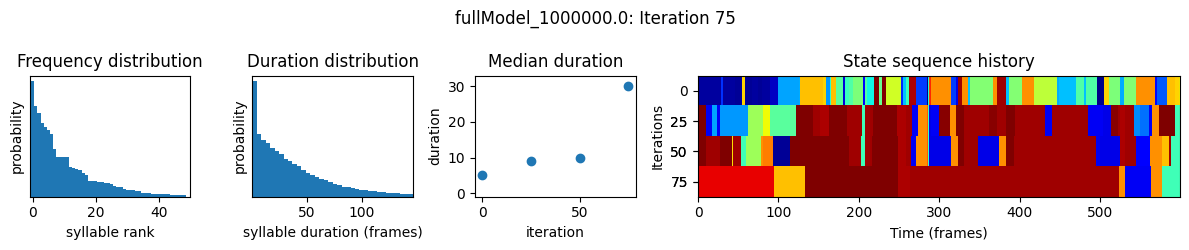

 17%|████▋                       | 50/301 [3:58:09<20:14:48, 290.39s/it]

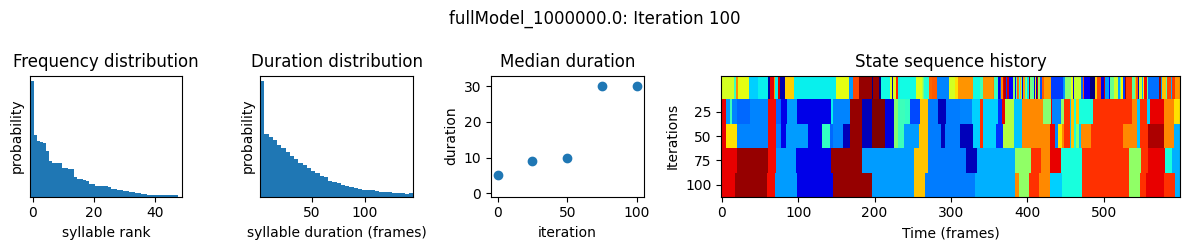

 25%|██████▉                     | 75/301 [5:55:25<16:22:45, 260.91s/it]

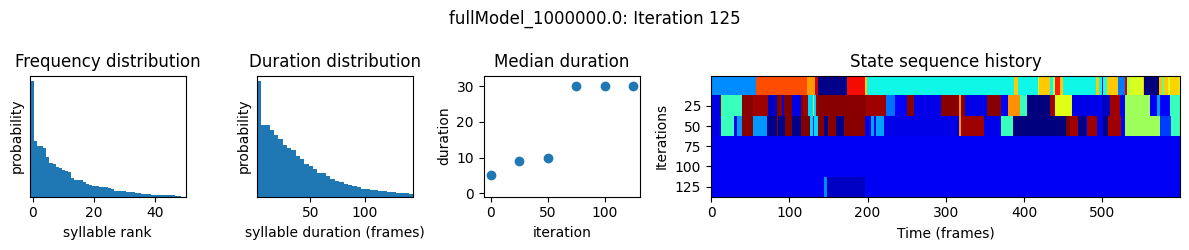

 33%|████████▉                  | 100/301 [7:48:58<14:20:11, 256.77s/it]

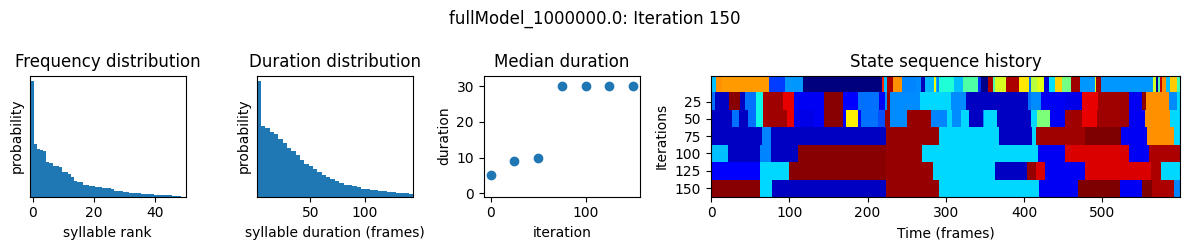

 42%|███████████▏               | 125/301 [9:46:12<14:51:24, 303.89s/it]

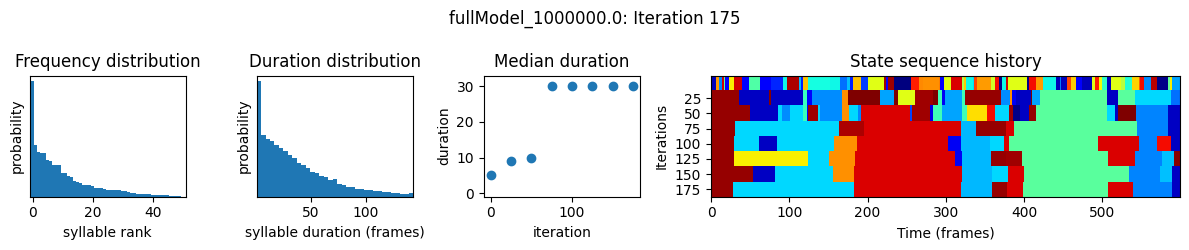

 50%|████████████▉             | 150/301 [11:39:05<10:41:36, 254.95s/it]

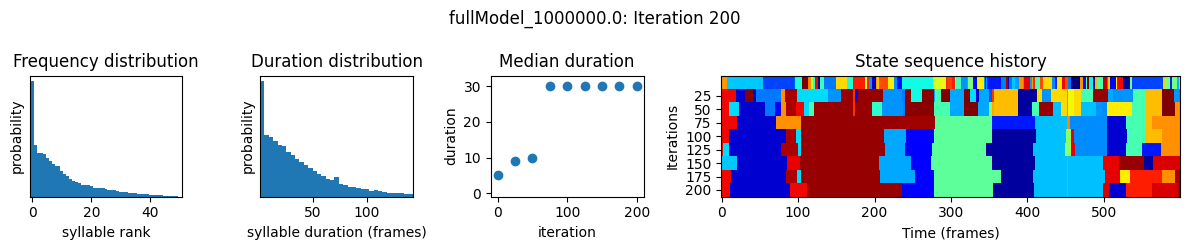

 58%|███████████████           | 175/301 [13:34:03<10:10:26, 290.69s/it]

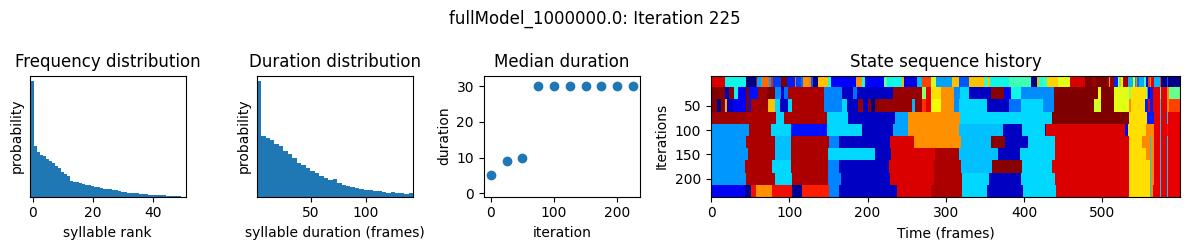

 60%|████████████████▏          | 180/301 [13:57:32<9:03:46, 269.64s/it]

: 

In [ ]:
'''
num_ar_iters = 50
kappa = 1e6
model_name = f"fullModel_{kappa}"

model = kpms.init_model(data, pca=pca, **config())
model = kpms.update_hypparams(model, kappa=kappa)

model, model_name = kpms.fit_model(model, 
                                   data, 
                                   metadata, 
                                   model_name = model_name, 
                                   project_dir = kpmoseq_dir, 
                                   ar_only=True, 
                                   num_iters=num_ar_iters
)

model, data, metadata, current_iter = kpms.load_checkpoint(kpmoseq_dir, 
                                                           model_name, 
                                                           iteration=num_ar_iters
)

model = kpms.fit_model(model,
                       data,
                       metadata,
                       kpmoseq_dir,
                       model_name,
                       ar_only=False,
                       start_iter=current_iter,
                       num_iters=current_iter + 300)[0]
'''

## Generating results

In [ ]:
kappa = 1e6
model_name = f"fullModel_{kappa}"

# modify a saved checkpoint so syllables are ordered by frequency
kpms.reindex_syllables_in_checkpoint(kpmoseq_dir, model_name);

model, data, metadata, current_iter = kpms.load_checkpoint(kpmoseq_dir,
                                                           model_name)


Reindexing: 100%|███████████| 13/13 [00:12<00:00,  1.03model snapshot/s]


In [ ]:
# extract results
results = kpms.extract_results(model, 
                               metadata, 
                               kpmoseq_dir, 
                               model_name)

Saved results to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR
\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\re
sults.h5


In [ ]:
results = kpms.load_results(kpmoseq_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, kpmoseq_dir, model_name, **config())

'\nresults = kpms.load_results(kpmoseq_dir, model_name)\nkpms.generate_trajectory_plots(coordinates, results, kpmoseq_dir, model_name, **config())\n'

In [ ]:

kpms.generate_grid_movies(results, kpmoseq_dir, model_name, coordinates=coordinates, **config(), overlay_keypoints=True);


Writing grid movies to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS_multiAnimal\fullModel_1000000.0\grid_movies
Using window size of 304 pixels


Generating grid movies: 100%|███████████| 33/33 [07:06<00:00, 12.93s/it]


In [ ]:

kpms.plot_similarity_dendrogram(coordinates, results, kpmoseq_dir, model_name, **config())

'\nkpms.plot_similarity_dendrogram(coordinates, results, kpmoseq_dir, model_name, **config())\n'

## Applying to entire dataset

In [ ]:
dataset = []

for f in dlc_folders_dataset:
    folder = Path(f).parent.parent 
    if (folder/"flag1.txt").exists() or not (folder/"flag.txt").exists():
        dataset.append(str(next(folder.rglob(rf"*{pcutoff}_skeleton\*snapshot_best-100_sk.h5"))))
    elif (folder/"flag.txt").exists() and not (folder/"flag1.txt").exists():
        dataset.append(str(next(folder.rglob(rf"*{pcutoff}_transformer\*snapshot_best-100_sk_tr.h5"))))

np.save(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR/dataset.npy",dataset)

Models:  [Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC_multiAnimal/trainingSessions_topView_KPMS_Resident/fullModel_100000.0'), Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC_multiAnimal/trainingSessions_topView_KPMS_Resident/fullModel_1000000.0'), Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC_multiAnimal/trainingSessions_topView_KPMS_Resident/fullModel_10000000.0'), Path('C:/Users/stagk/OneDrive/Desktop/trainingAggression_MR/trainingSessions/trainingSessions_topView_DLC_multiAnimal/trainingSessions_topView_KPMS_Resident/fullModel_100000000.0')]


100%|█████████████████████████████████████| 4/4 [01:44<00:00, 26.24s/it]


Best model: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_KPMS_Resident\fullModel_100000.0


(<Figure size 400x350 with 1 Axes>, <Axes: ylabel='EML score'>)

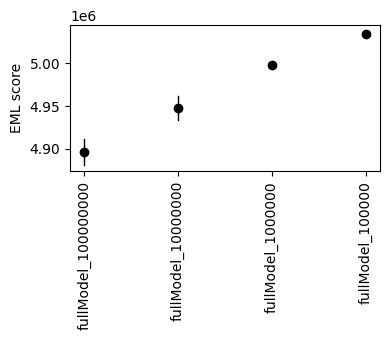

In [ ]:
model_names = [f for f in Path(kpmoseq_dir).rglob("fullModel*")]
print("Models: ", model_names)

eml_scores, eml_std_errs = kpms.expected_marginal_likelihoods(kpmoseq_dir, model_names)
best_model = model_names[np.argmax(eml_scores)]
print(f"\nBest model: {best_model}")

kpms.plot_eml_scores(eml_scores, eml_std_errs, [str(Path(f).stem) for f in model_names])

In [ ]:
def extract_id(k):
    m = re.search(r"(mouse\d+).*?Day(\d+)", k)
    if not m:
        return None
    return f"{m.group(1)}_Day{m.group(2)}"

def clean_keys(d):
    new_d = {}
    for k, v in d.items():
        new_key = extract_id(k)
        if new_key is None:
            continue  # or raise error if you prefer
        new_d[new_key] = v
    return new_d

In [ ]:
# The model with kappa = 1e5 generates syllables with a median duration of around 23 frames = 460ms

b_model = kpms.load_checkpoint(kpmoseq_dir, best_model)[0]

# load new data (e.g. from deeplabcut)
new_data = dataset
coordinates, confidences, bodyparts = kpms.load_keypoints(new_data, 
                                                          "deeplabcut", 
                                                          path_in_name=True, 
                                                          exclude_individuals=exclude)

coordinates = clean_keys(coordinates)
confidences = clean_keys(confidences)

coordinates, confidences = kpms.outlier_removal(coordinates,
                                                confidences,
                                                kpmoseq_dir,
                                                overwrite=False,
                                                **config())

data, metadata = kpms.format_data(coordinates, 
                                  confidences, 
                                  **config())

Loading keypoints:   1%|▏               | 3/249 [00:01<02:01,  2.02it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:   2%|▎               | 5/249 [00:02<01:08,  3.55it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:   4%|▌               | 9/249 [00:02<00:35,  6.72it/s]

...

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints:  99%|█████████████▉| 247/249 [00:20<00:00, 12.60it/s]

Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.
Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


Loading keypoints: 100%|██████████████| 249/249 [00:20<00:00, 11.96it/s]


Excluding individual: "Intruder". Set `exclude_individuals=[]` to include.
Excluding individual: "single". Set `exclude_individuals=[]` to include.


In [ ]:
print(best_model.stem)

fullModel_100000


In [ ]:
bk_model["hypparams"]["trans_hypparams"]

{'alpha': 5.7, 'gamma': 1000.0, 'kappa': 100000.0, 'num_states': 100}

In [ ]:
# apply saved model to new data
results = kpms.apply_model(best_model, 
                           data, 
                           metadata, 
                           kpmoseq_dir, 
                           best_model.stem + ".0",
                           overwrite = True,
                           **config())

NameError: name 'data' is not defined

In [ ]:
kpmoseq_dir

'C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\trainingSessions_topView_DLC_multiAnimal\\trainingSessions_topView_KPMS_Resident'

In [ ]:
kappa = 1e6
bestModel = fr"fullModel_{kappa}"

results = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_DLC_multiAnimal\trainingSessions_topView_KPMS_Resident\fullModel_1000000.0\results.h5")

results = kpms.load_results(kpmoseq_dir, bestModel, results)

filtered_results = {
    k: v for k, v in results.items()
    if "_topView_compDLC_" not in k # These were keys that come from a previous iteration of the model training. They have duplicates in the correct format 
}


In [ ]:
results

{'mouse1010819_Day02': {'centroid': array([[279.6375189 , 181.77846713],
         [280.40619705, 183.15760019],
         [278.56300594, 180.71918016],
         ...,
         [220.11732492, 162.06073211],
         [220.31779839, 161.15915325],
         [220.06848423, 161.32297432]]),
  'heading': array([-2.81974673, -2.90227009, -2.56872941, ...,  1.25134814,
          1.30406846,  1.28574532]),
  'latent_state': array([[ 3.06113701e+00, -4.05976444e-02,  5.14756844e-03,
          -4.24962658e-01,  4.40024650e+00],
         [-1.36430648e+00, -7.14568817e+00,  5.71485549e+00,
           1.11180196e+00,  1.90274387e+00],
         [ 1.45680590e+00, -6.95833879e-01, -4.04447195e-01,
           3.18247551e-01, -1.68311064e+00],
         ...,
         [ 6.31860553e-01, -5.80138731e-01, -6.99399678e-01,
           7.89849427e-01,  4.32693695e-01],
         [ 6.37299331e-01, -5.50829481e-01, -6.14771548e-01,
           8.14205191e-01,  4.68724545e-01],
         [ 7.50811734e-01, -5.39266273e-01

In [ ]:
filtered_results

{'mouse1010819_Day02': {'centroid': array([[279.6375189 , 181.77846713],
         [280.40619705, 183.15760019],
         [278.56300594, 180.71918016],
         ...,
         [220.11732492, 162.06073211],
         [220.31779839, 161.15915325],
         [220.06848423, 161.32297432]]),
  'heading': array([-2.81974673, -2.90227009, -2.56872941, ...,  1.25134814,
          1.30406846,  1.28574532]),
  'latent_state': array([[ 3.06113701e+00, -4.05976444e-02,  5.14756844e-03,
          -4.24962658e-01,  4.40024650e+00],
         [-1.36430648e+00, -7.14568817e+00,  5.71485549e+00,
           1.11180196e+00,  1.90274387e+00],
         [ 1.45680590e+00, -6.95833879e-01, -4.04447195e-01,
           3.18247551e-01, -1.68311064e+00],
         ...,
         [ 6.31860553e-01, -5.80138731e-01, -6.99399678e-01,
           7.89849427e-01,  4.32693695e-01],
         [ 6.37299331e-01, -5.50829481e-01, -6.14771548e-01,
           8.14205191e-01,  4.68724545e-01],
         [ 7.50811734e-01, -5.39266273e-01

Saving trajectory plots to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\trajectory_plots


Generating trajectory plots: 100%|██████| 31/31 [00:24<00:00,  1.25it/s]


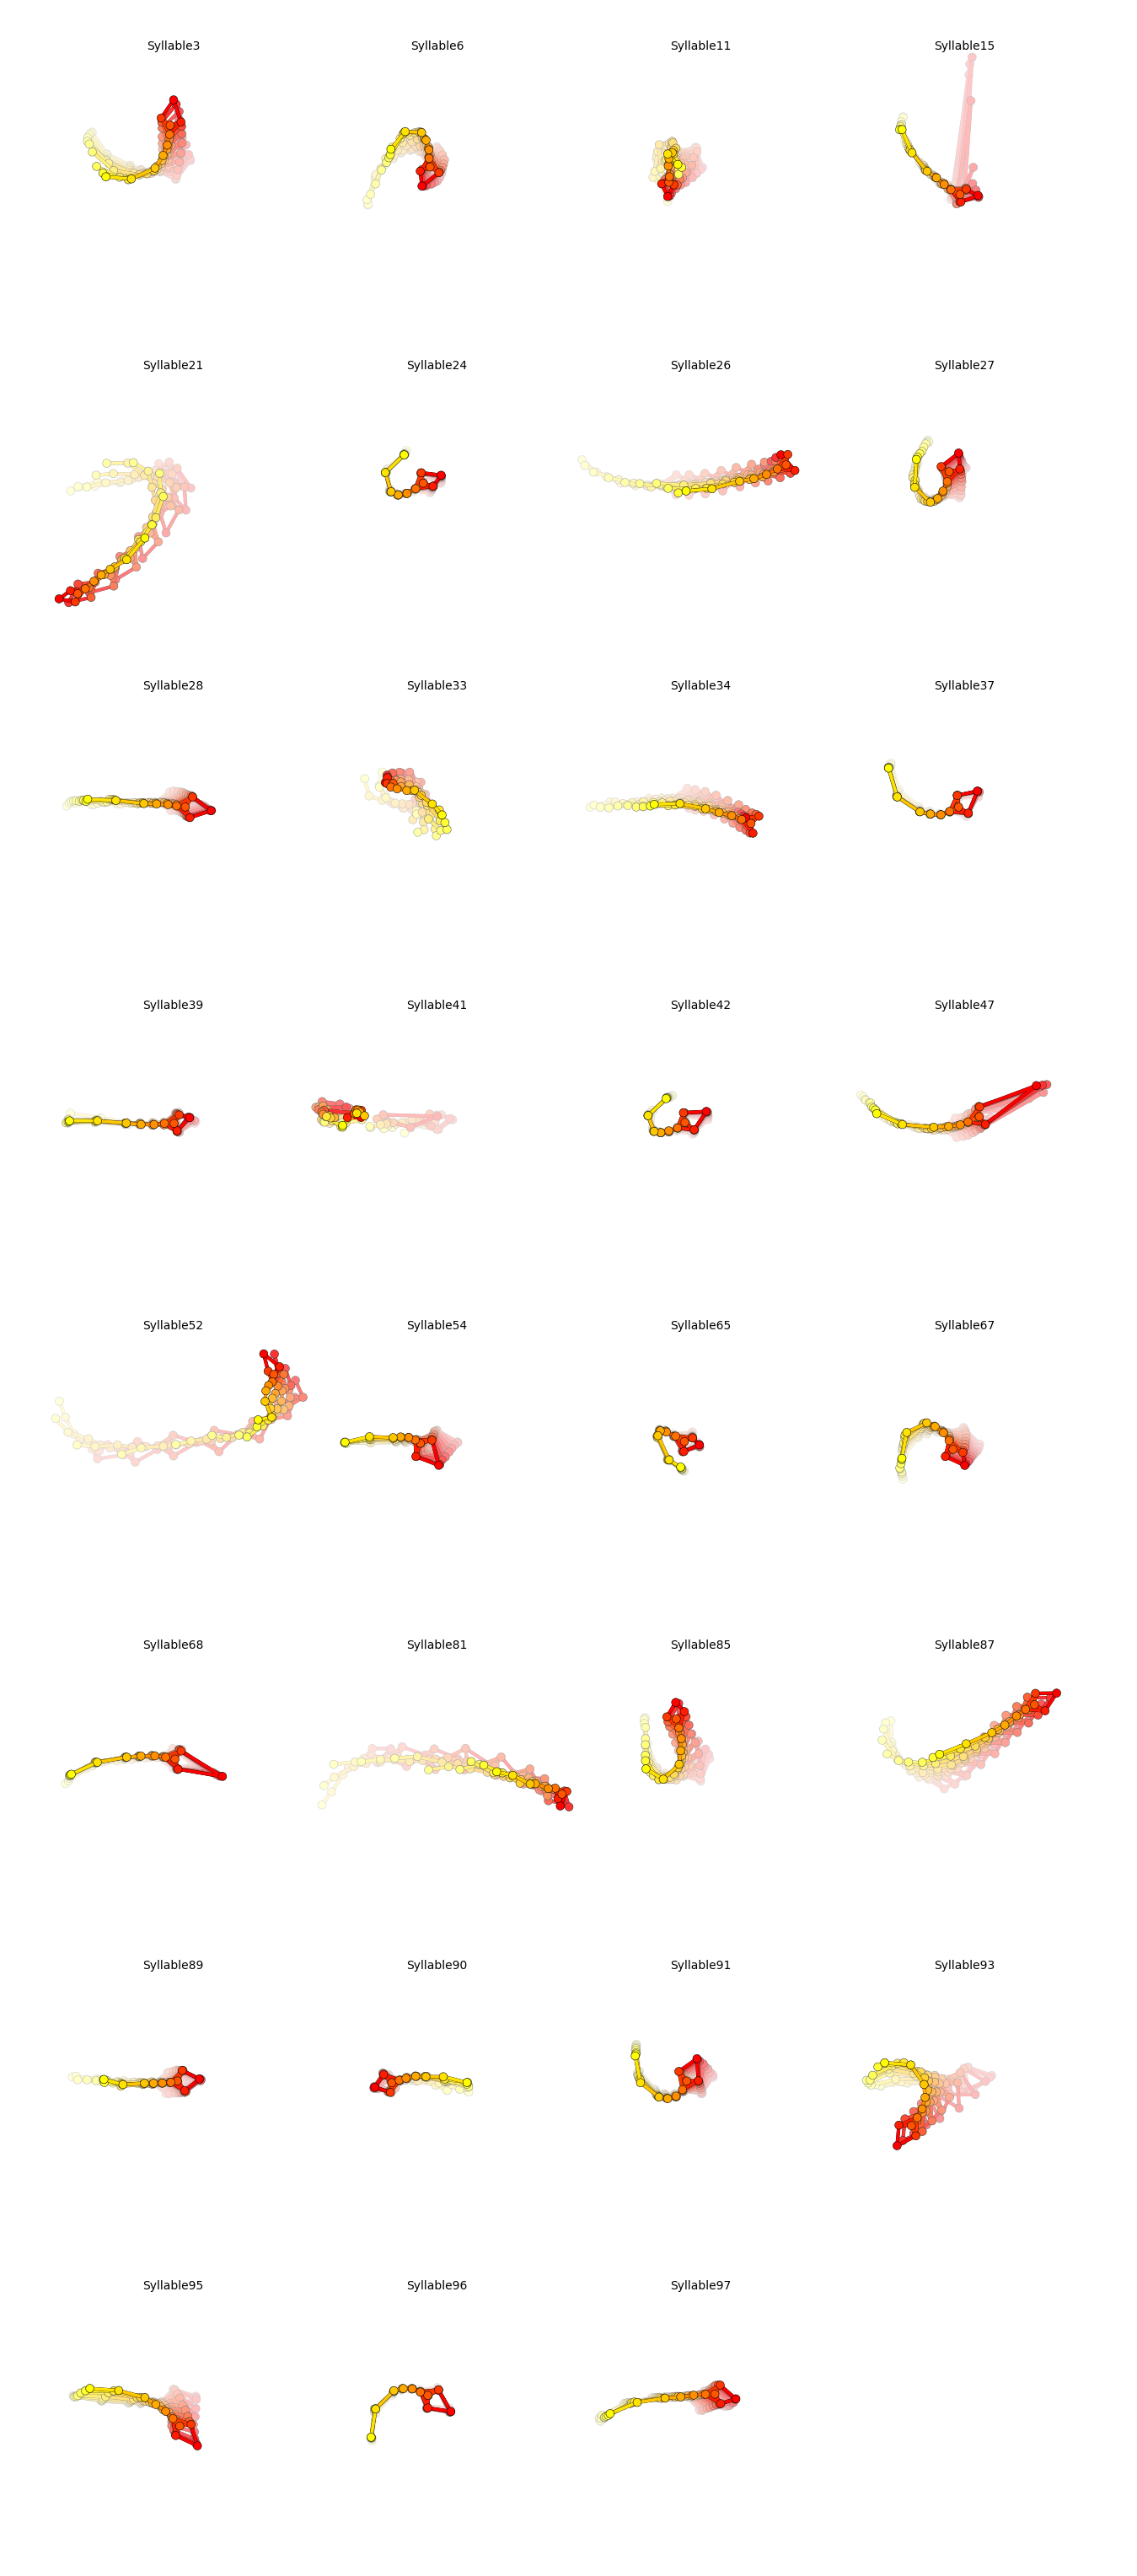

In [ ]:
kpms.generate_trajectory_plots(coordinates, filtered_results, kpmoseq_dir, model_name, **config())

In [ ]:
key_path = {}
for k in coordinates.keys():
    for p in new_data:
        if k in p:
            P = next(Path(p).parent.parent.glob("*topView*.avi"))
            key_path[k] = str(P)

NameError: name 'coordinates' is not defined

In [ ]:
kpms.generate_grid_movies(filtered_results, kpmoseq_dir, model_name, video_paths = key_path, coordinates=coordinates, **config(), overlay_keypoints=True)

Writing grid movies to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\grid_movies
Using window size of 304 pixels


Generating grid movies: 100%|███████████| 31/31 [07:56<00:00, 15.37s/it]


Saving dendrogram plot to C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions_topView_KPMS\fullModel_1000000.0\similarity_dendrogram


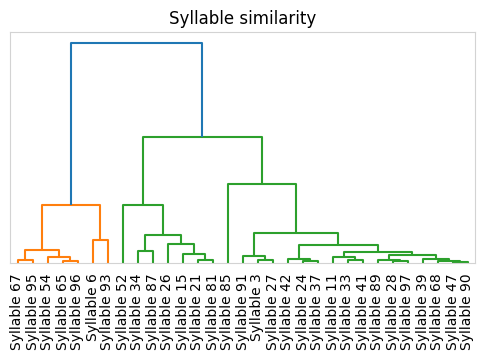

In [ ]:
kpms.plot_similarity_dendrogram(coordinates, filtered_results, kpmoseq_dir, model_name, **config())

## Results analysis

In [ ]:
# Groups

Agg = ["975826", "975827", "975833", "978772", "978774", "988590", "997838", "1010820", "1010823", "1010826", "1029741"]
nonAgg = ["975830", "978775", "1010819", "997839", "997840", "997841", "1029736", "1029739", "1032216"]
maladaptive = ["978513", "978527", "978528", "1010832", "1013590", "1034805", "1034814"]

In [ ]:
if filtered_results["mouse1013590_Day19"]:
    del filtered_results["mouse1013590_Day19"]

In [ ]:
rows = []
skipped = []

saline_mice = maladaptive[:3]
psilo_mice = maladaptive[3:]   # non-overlapping

for video in filtered_results.keys():

    m = re.match(r"mouse(\d+)_Day(\d+)", video)

    if m is None:
        skipped.append({"recording": video, "reason": "regex_no_match"})
        continue

    mouse = m.group(1)
    day = int(m.group(2))

    if mouse in Agg:
        group = "Agg"

    elif mouse in nonAgg:
        group = "nonAgg"

    elif mouse in maladaptive and day <= 5:
        group = "maladaptive baseline"

    elif mouse in psilo_mice and day >= 15:
        group = "maladaptive after Psilocybin"

    elif mouse in saline_mice and day >= 15:
        group = "maladaptive after Saline"

    else:
        skipped.append({
            "recording": video,
            "mouse": mouse,
            "day": day,
            "reason": "mouse_not_in_group_lists"
        })
        continue

    mouse_group_id = f"{mouse}_{group}"

    rows.append({
        "video": video,
        "mouse": mouse,                 # original animal ID
        "mouse_group_id": mouse_group_id, # analysis ID
        "day": day,
        "group": group
    })

resultsDataset = pd.DataFrame(rows)
skipped_df = pd.DataFrame(skipped)

In [ ]:
all_syllables=[]

for rec in filtered_results:
    all_syllables.extend(
        filtered_results[rec]["syllable"]
    )

n_syll = len(np.unique(all_syllables))

In [41]:
filtered_results

{'mouse1010819_Day02': {'centroid': array([[279.6375189 , 181.77846713],
         [280.40619705, 183.15760019],
         [278.56300594, 180.71918016],
         ...,
         [220.11732492, 162.06073211],
         [220.31779839, 161.15915325],
         [220.06848423, 161.32297432]]),
  'heading': array([-2.81974673, -2.90227009, -2.56872941, ...,  1.25134814,
          1.30406846,  1.28574532]),
  'latent_state': array([[ 3.06113701e+00, -4.05976444e-02,  5.14756844e-03,
          -4.24962658e-01,  4.40024650e+00],
         [-1.36430648e+00, -7.14568817e+00,  5.71485549e+00,
           1.11180196e+00,  1.90274387e+00],
         [ 1.45680590e+00, -6.95833879e-01, -4.04447195e-01,
           3.18247551e-01, -1.68311064e+00],
         ...,
         [ 6.31860553e-01, -5.80138731e-01, -6.99399678e-01,
           7.89849427e-01,  4.32693695e-01],
         [ 6.37299331e-01, -5.50829481e-01, -6.14771548e-01,
           8.14205191e-01,  4.68724545e-01],
         [ 7.50811734e-01, -5.39266273e-01

In [ ]:
import numpy as np
import pandas as pd

# =============================================================
# SOURCES  --  point these at your own variables
# =============================================================
SYLL_RESULTS = filtered_results   # dict: video -> {"syllable": [...]}  (your syllable sequences)
META_DF      = resultsDataset     # DataFrame with a "video" column (+ "mouse", "group", ...)

# =============================================================
# SYLLABLE FILTER (label-blind) + FEATURE CONSTRUCTION
# =============================================================
# A syllable is kept only if it is used (> SYLL_MIN_USAGE fraction of frames)
# in at least SYLL_MIN_RECORDINGS recordings. Filtered syllables are dropped
# from BOTH the usage features and the transition matrix, so the n_syll^2
# transition block shrinks to kept^2 among present syllables.
SYLL_MIN_USAGE      = 0.01  # >0.5% of frames in a recording counts as "used"
SYLL_MIN_RECORDINGS = 5       # must be used in >= this many recordings

# renormalise kept-syllable frequencies to sum to 1 per recording
RENORM_USAGE = True

# transition semantics for filtered syllables:
#   False -> count only DIRECT kept->kept transitions (a filtered step breaks the chain)
#   True  -> drop filtered syllables from the sequence first, so i -> [filtered] -> j
#            is counted as a direct i -> j (bridges gaps)
BRIDGE_GAPS = False


def usage_freq(s, n):
    s = np.asarray(s)
    if len(s) == 0:
        return np.zeros(n)
    return np.bincount(s, minlength=n)[:n] / len(s)


def transition_counts(s, n):
    M = np.zeros((n, n))
    s = np.asarray(s)
    if len(s) > 1:
        np.add.at(M, (s[:-1], s[1:]), 1)
    return M


# recordings we actually have syllable sequences for
recs = list(SYLL_RESULTS.keys())

# IMPORTANT: array size must span the LARGEST syllable label + 1, NOT the count
# of distinct labels. Syllable IDs are non-contiguous (e.g. labels up to 90 but
# only 57 distinct), so len(np.unique(...)) undersizes the matrices and both
# crashes transition_counts and silently truncates usage_freq. Recompute here.
n_syll = 1 + max(
    int(np.asarray(SYLL_RESULTS[rec]["syllable"]).max())
    for rec in recs
    if len(np.asarray(SYLL_RESULTS[rec]["syllable"])) > 0
)
print(f"label span n_syll = {n_syll} (max label + 1)")

# ---- 1. decide which syllables survive the filter ----
freq_mat = np.vstack([usage_freq(SYLL_RESULTS[rec]["syllable"], n_syll) for rec in recs])
present  = (freq_mat > SYLL_MIN_USAGE).sum(axis=0)
kept     = np.where(present >= SYLL_MIN_RECORDINGS)[0]          # sorted original indices
print(f"kept {len(kept)} / {n_syll} syllables "
      f"-> {len(kept)} usage + {len(kept)**2} transition features")

# ---- 2. build syll_ + trans_ features on the kept syllables only ----
rows = []
for rec in recs:
    s = np.asarray(SYLL_RESULTS[rec]["syllable"])

    # usage over kept syllables (original indices preserved in the names)
    freq = usage_freq(s, n_syll)[kept]
    if RENORM_USAGE and freq.sum() > 0:
        freq = freq / freq.sum()

    # transitions among kept syllables
    if BRIDGE_GAPS:
        s_sub = s[np.isin(s, kept)]              # remove filtered syllables from the chain
        s_sub = np.searchsorted(kept, s_sub)     # remap originals -> 0..len(kept)-1
        C = transition_counts(s_sub, len(kept))
    else:
        C = transition_counts(s, n_syll)[np.ix_(kept, kept)]   # direct kept->kept only

    rowsum = C.sum(1, keepdims=True)
    P = np.divide(C, rowsum, where=rowsum > 0, out=np.zeros_like(C))

    row = {"video": rec}
    row.update({f"syll_{orig}": freq[k] for k, orig in enumerate(kept)})
    row.update({f"trans_{a}_{b}": P[ka, kb]
                for ka, a in enumerate(kept)
                for kb, b in enumerate(kept)})
    rows.append(row)

# attach metadata (mouse, group, ...); inner merge drops recordings without metadata
df = META_DF.merge(pd.DataFrame(rows).fillna(0), on="video", how="inner")
print("final df:", df.shape, "| mice:", df["mouse"].nunique())

label span n_syll = 99 (max label + 1)
kept 33 / 99 syllables -> 33 usage + 1089 transition features
final df: (247, 1127) | mice: 27


In [ ]:
mouse_df = (
    df.groupby(["mouse_group_id", "group"])
    .mean(numeric_only=True)
    .reset_index()
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# =============================================================
# HYPERPARAMETERS
# =============================================================
# "none" | "variance" | "dispersion" | "laplacian" | "mutual_info"
FEATURE_SELECTION_METHOD = "variance"

# fraction of valid features to keep (ignored when method == "none")
FEATURE_FRACTION = 0.7
LAPLACIAN_K = 3
RANDOM_STATE = 42

# which feature blocks to feed the pipeline: syllable usage and/or transitions
FEATURE_REGEX = r"^(syll|trans)_"

# -----------------------------
# settings
# -----------------------------
group_colors = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
group_order = ["nonAgg", "Agg", "maladaptive"]

pc_cmap = LinearSegmentedColormap.from_list(
    "blue_orange_red", ["#5AA2E6", "#E6A55A", "#E65A5A"])

# -----------------------------
# keep nonAgg, Agg, and maladaptive BASELINE only
# (after-Saline / after-Psilocybin are repeat recordings of the same mice
#  -> excluded to avoid pseudoreplication; they are NOT merged in)
# -----------------------------
plot_df = mouse_df.copy()
plot_df = plot_df[plot_df["group"].isin(["nonAgg", "Agg", "maladaptive baseline"])].copy()
plot_df["group_merged"] = plot_df["group"].replace({"maladaptive baseline": "maladaptive"})
print(plot_df["group_merged"].value_counts().to_string())

# -----------------------------
# features  (syllables + transitions)
# -----------------------------
X_df = plot_df.filter(regex=FEATURE_REGEX).copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# no floor (you found the algorithm works better without it)
min_recordings = 1
presence = (X_df > 0).sum(axis=0)
valid_features = presence[presence >= min_recordings].index
X_df = X_df[valid_features]

X_log = np.log(X_df + 1e-8)

top_n = max(1, int(len(valid_features) * FEATURE_FRACTION))

y = LabelEncoder().fit_transform(plot_df["group_merged"])


# =============================================================
# feature-selection dispatch
# =============================================================
def select_features(method, X_df, X_log, y, top_n, k=5, random_state=42):
    """Return an Index of selected feature names according to `method`."""
    if method == "none":
        return X_df.columns

    if method == "variance":
        scores = X_log.var(axis=0)
        return scores.sort_values(ascending=False).head(top_n).index

    if method == "dispersion":
        mean = X_df.mean(axis=0)
        std = X_df.std(axis=0)
        scores = std / mean.replace(0, np.nan)
        scores = scores.replace([np.inf, -np.inf], np.nan).fillna(0)
        return scores.sort_values(ascending=False).head(top_n).index

    if method == "laplacian":
        try:
            from skfeature.function.similarity_based import lap_score
            from skfeature.utility.construct_W import construct_W
        except ImportError as e:
            raise ImportError(
                "The 'laplacian' method needs skfeature. Install it with:\n"
                "    pip install skfeature-chappers"
            ) from e
        X_all = StandardScaler().fit_transform(X_log)
        W = construct_W(X_all, metric="euclidean", neighbor_mode="knn",
                        weight_mode="heat_kernel", k=k, t=1)
        scores = lap_score.lap_score(X_all, W=W)   # lower score = better
        ranks = np.argsort(scores)
        return X_df.columns[ranks[:top_n]]

    if method == "mutual_info":
        # SUPERVISED -- uses group labels, circular. Kept only for comparison.
        X_scaled = StandardScaler().fit_transform(X_log)
        mi = mutual_info_classif(X_scaled, y, random_state=random_state)
        scores = pd.Series(mi, index=X_df.columns).sort_values(ascending=False)
        return scores.head(top_n).index

    raise ValueError(
        f"Unknown FEATURE_SELECTION_METHOD={method!r}. "
        "Choose one of: 'none', 'variance', 'dispersion', 'laplacian', 'mutual_info'."
    )


top_features = select_features(
    FEATURE_SELECTION_METHOD, X_df, X_log, y, top_n,
    k=LAPLACIAN_K, random_state=RANDOM_STATE,
)

# how many of the selected features are usage vs transitions (sanity check)
n_syll_sel = sum(str(f).startswith("syll_") for f in top_features)
n_trans_sel = sum(str(f).startswith("trans_") for f in top_features)
print(f"[feature selection] method = {FEATURE_SELECTION_METHOD}")
print(f"[feature selection] kept {len(top_features)} / {len(valid_features)} features "
      f"({n_syll_sel} usage, {n_trans_sel} transitions)")

# -----------------------------
# PCA
# -----------------------------
X_selected = X_log[top_features]
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=2)
Y = pca.fit_transform(X_selected_scaled)

plot_df["PC1"] = Y[:, 0]
plot_df["PC2"] = Y[:, 1]

# -----------------------------
# PC1 loadings
# -----------------------------
pc1_weights = pd.Series(pca.components_[0], index=top_features, name="PC1_weight")

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)

# -----------------------------
# PC1 distribution data
# -----------------------------
violin_data = [
    plot_df.loc[plot_df["group_merged"] == g, "PC1"].values
    for g in group_order
]

# -----------------------------
# per-group feature contribution to PC1
# -----------------------------
X_selected_df = pd.DataFrame(X_selected_scaled, columns=top_features, index=plot_df.index)

pc1_contrib = X_selected_df.mul(pc1_weights, axis=1)
pc1_contrib["group"] = plot_df["group_merged"].values

group_pc1_contrib = pc1_contrib.groupby("group").mean().T

# cap the heatmap: with transitions top_n can be huge, so show the 30 strongest
top_heat_n = min(top_n, 30)

top_syllables = (
    group_pc1_contrib.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(top_heat_n)
    .index
)

heat = group_pc1_contrib.loc[top_syllables, group_order]

max_abs = max(np.abs(top_loadings.values).max(), np.abs(heat.values).max())

norm = Normalize(vmin=-max_abs, vmax=max_abs)
sm = ScalarMappable(norm=norm, cmap=pc_cmap)
sm.set_array([])

group_merged
Agg            11
nonAgg          9
maladaptive     7
[feature selection] method = variance
[feature selection] kept 525 / 751 features (14 usage, 511 transitions)


In [ ]:
top_n

525

[sign] flipped PC1 so 'maladaptive' scores highest


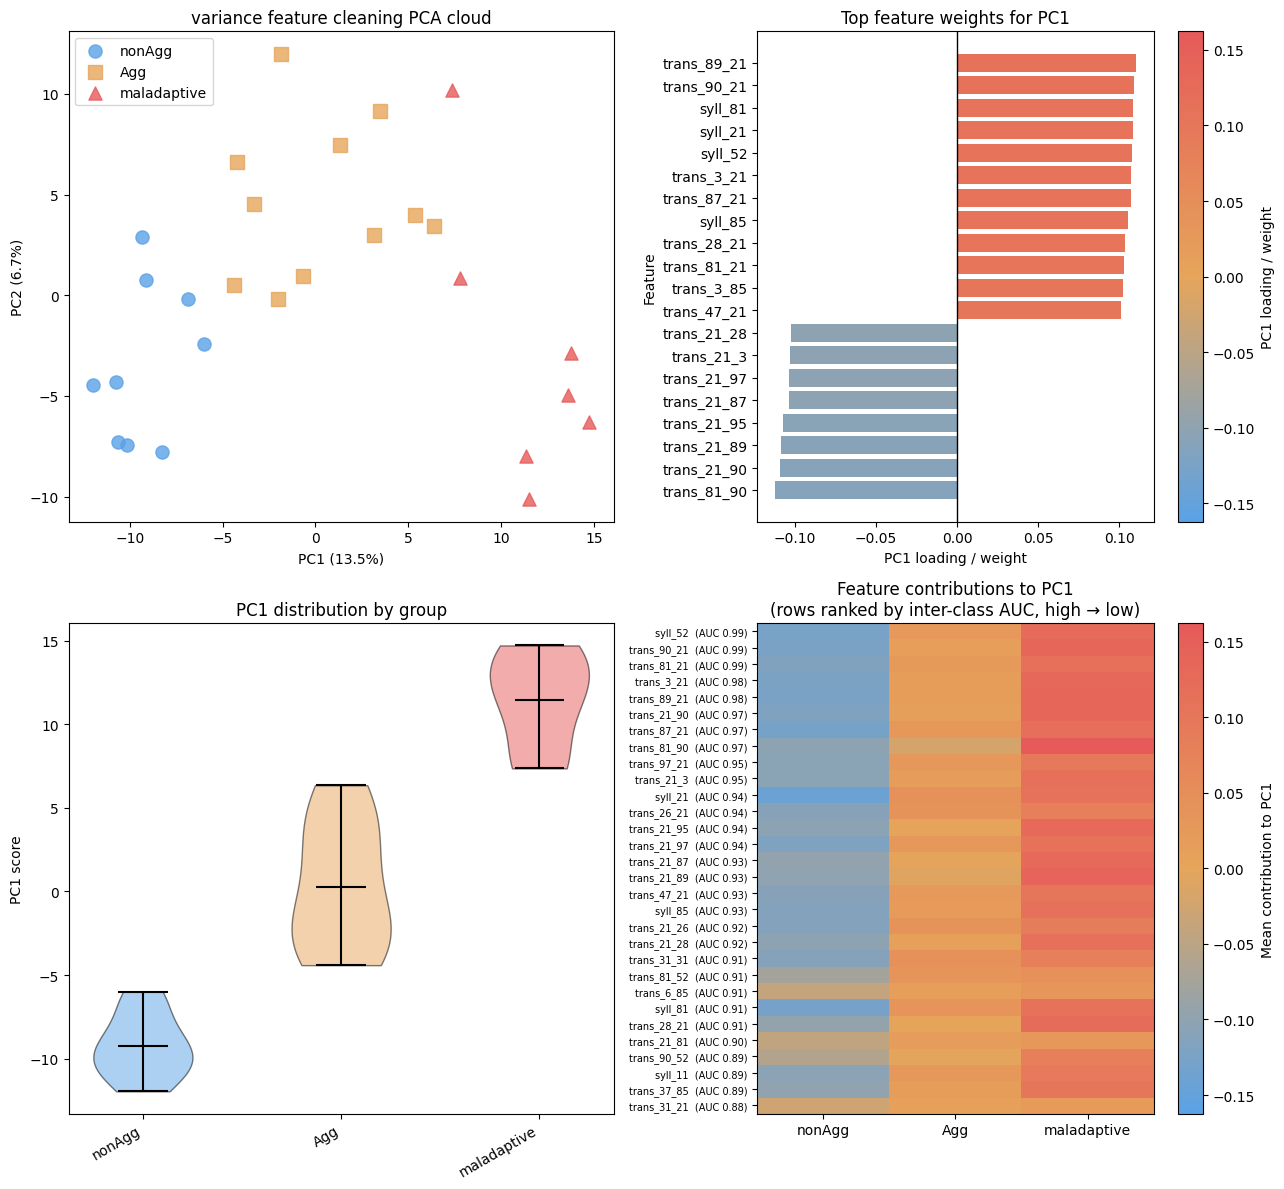

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from itertools import combinations
from sklearn.metrics import roc_auc_score

# =============================================================
# 0. sign convention -- flip PC1 so SIGN_ANCHOR_GROUP scores highest,
#    then RECOMPUTE every sign-dependent quantity so all 4 panels agree.
#    (idempotent: if it's already oriented, nothing flips.)
# =============================================================
SIGN_ANCHOR_GROUP = "maladaptive"

if plot_df.groupby("group_merged")["PC1"].mean().idxmax() != SIGN_ANCHOR_GROUP:
    plot_df["PC1"] = -plot_df["PC1"]
    pca.components_[0] = -pca.components_[0]
    print(f"[sign] flipped PC1 so '{SIGN_ANCHOR_GROUP}' scores highest")
else:
    print(f"[sign] PC1 already oriented with '{SIGN_ANCHOR_GROUP}' highest")

# --- recompute loadings / violins / contributions from the (possibly flipped) sign ---
pc1_weights = pd.Series(pca.components_[0], index=top_features, name="PC1_weight")

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)

violin_data = [
    plot_df.loc[plot_df["group_merged"] == g, "PC1"].values
    for g in group_order
]

X_selected_df = pd.DataFrame(X_selected_scaled, columns=top_features, index=plot_df.index)
pc1_contrib = X_selected_df.mul(pc1_weights, axis=1)
pc1_contrib["group"] = plot_df["group_merged"].values
group_pc1_contrib = pc1_contrib.groupby("group").mean().T

# =============================================================
# rank features by inter-class separability (mean pairwise AUC, orientation-agnostic)
# AUC is rank-based, so z-scored/log values give the same result as raw usage.
# =============================================================
labels_arr = plot_df["group_merged"].values


def separation_auc(values, labels, classes):
    aucs = []
    for a, b in combinations(classes, 2):
        mask = np.isin(labels, [a, b])
        y_bin = (labels[mask] == a).astype(int)
        if len(np.unique(y_bin)) < 2:
            continue
        auc = roc_auc_score(y_bin, values[mask])
        aucs.append(max(auc, 1 - auc))     # direction-agnostic separability in [0.5, 1]
    return np.mean(aucs) if aucs else np.nan


auc_sep = pd.Series(
    {f: separation_auc(X_selected_df[f].values, labels_arr, group_order)
     for f in group_pc1_contrib.index},
    name="sep_auc",
)

top_heat_n = min(30, group_pc1_contrib.shape[0])
top_features_ranked = auc_sep.sort_values(ascending=False).head(top_heat_n).index

heat = group_pc1_contrib.loc[top_features_ranked, group_order]
heat.index = [f"{f}  (AUC {auc_sep[f]:.2f})" for f in top_features_ranked]   # show AUC in row label

# shared colour scale for loading barplot + heatmap
max_abs = max(np.abs(top_loadings.values).max(), np.abs(heat.values).max())
norm = Normalize(vmin=-max_abs, vmax=max_abs)
sm = ScalarMappable(norm=norm, cmap=pc_cmap)
sm.set_array([])

# =============================================================
# figure
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 12), gridspec_kw={"width_ratios": [1.1, 1]})

# -----------------------------
# 1. PCA cloud
# -----------------------------
ax = axes[0, 0]
for g in group_order:
    idx = plot_df["group_merged"] == g
    ax.scatter(plot_df.loc[idx, "PC1"], plot_df.loc[idx, "PC2"],
               label=g, color=group_colors[g], marker=group_markers[g], alpha=0.8, s=90)
ax.legend(loc="upper left")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title(f"{FEATURE_SELECTION_METHOD} feature cleaning PCA cloud")

# -----------------------------
# 2. Top PC1 feature weights
# -----------------------------
ax = axes[0, 1]
bar_colors = [pc_cmap(norm(v)) for v in top_loadings.values]
ax.barh(top_loadings.index, top_loadings.values, color=bar_colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("PC1 loading / weight")
ax.set_ylabel("Feature")
ax.set_title("Top feature weights for PC1")
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PC1 loading / weight")

# -----------------------------
# 3. PC1 violin plot by group
# -----------------------------
ax = axes[1, 0]
vp = ax.violinplot(violin_data, showmeans=True, showmedians=False)
for body, g in zip(vp["bodies"], group_order):
    body.set_facecolor(group_colors[g]); body.set_edgecolor("black"); body.set_alpha(0.5)
for key in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[key].set_color("black")
ax.set_xticks(np.arange(1, len(group_order) + 1))
ax.set_xticklabels(group_order, rotation=30, ha="right")
ax.set_ylabel("PC1 score")
ax.set_title("PC1 distribution by group")

# -----------------------------
# 4. Feature contributions to PC1, rows ranked by inter-class AUC
# -----------------------------
ax = axes[1, 1]
im = ax.imshow(heat, aspect="auto", cmap=pc_cmap, norm=norm)
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=7)
ax.set_title("Feature contributions to PC1\n(rows ranked by inter-class AUC, high → low)")
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Mean contribution to PC1")

plt.tight_layout()
plt.savefig("pc1_panels_auc_ranked.png", dpi=200, bbox_inches="tight")
plt.show()

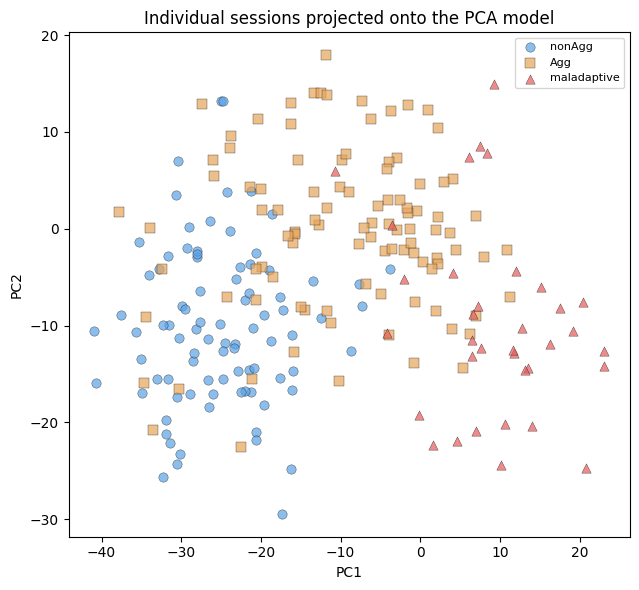

In [ ]:
# project individual sessions onto the already-fitted PCA (reuses pca, top_features, X_log)
scaler = StandardScaler().fit(X_log[top_features])            # same transform PCA was trained on

# keep nonAgg, Agg, maladaptive BASELINE only (exclude after-Saline / after-Psilocybin sessions)
sess = df[df["group"].isin(["nonAgg", "Agg", "maladaptive baseline"])].copy()
sess["group_merged"] = sess["group"].replace({"maladaptive baseline": "maladaptive"})

feat = sess.reindex(columns=top_features).replace([np.inf, -np.inf], np.nan).fillna(0)
proj = pca.transform(scaler.transform(np.log(feat + 1e-8)))   # sign already matches the flipped axis
sess["PC1"], sess["PC2"] = proj[:, 0], proj[:, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
for g in group_order:
    sub = sess[sess["group_merged"] == g]
    ax.scatter(sub["PC1"], sub["PC2"], s=45, alpha=0.7, label=g,
               color=group_colors[g], marker=group_markers[g], edgecolor="black", linewidth=0.3)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Individual sessions projected onto the PCA model")
ax.legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()

In [46]:
cols = [c for c in ["video", "mouse_group_id", "day", "group", "PC1"] if c in sess.columns]
N = 10   # how many extremes to show per end

for g in group_order:
    sub = sess[sess["group_merged"] == g].sort_values("PC1")
    print(f"\n===== {g}  (n = {len(sub)}) =====")
    print("--- lowest PC1 ---")
    print(sub[cols].head(N).to_string(index=False))
    print("--- highest PC1 ---")
    print(sub[cols].tail(N)[::-1].to_string(index=False))


===== nonAgg  (n = 87) =====
--- lowest PC1 ---
             video mouse_group_id  day  group        PC1
mouse1029739_Day08 1029739_nonAgg    8 nonAgg -40.942563
 mouse997839_Day08  997839_nonAgg    8 nonAgg -40.635760
mouse1010819_Day02 1010819_nonAgg    2 nonAgg -37.528232
mouse1029736_Day02 1029736_nonAgg    2 nonAgg -35.650283
mouse1029739_Day06 1029739_nonAgg    6 nonAgg -35.353778
mouse1032216_Day10 1032216_nonAgg   10 nonAgg -35.062540
mouse1029739_Day05 1029739_nonAgg    5 nonAgg -34.908309
mouse1010819_Day12 1010819_nonAgg   12 nonAgg -34.037352
mouse1032216_Day09 1032216_nonAgg    9 nonAgg -33.052760
 mouse997839_Day02  997839_nonAgg    2 nonAgg -32.819161
--- highest PC1 ---
             video mouse_group_id  day  group        PC1
 mouse997840_Day05  997840_nonAgg    5 nonAgg  -3.765977
 mouse978775_Day11  978775_nonAgg   11 nonAgg  -7.354615
mouse1032216_Day04 1032216_nonAgg    4 nonAgg  -7.639034
 mouse978775_Day03  978775_nonAgg    3 nonAgg  -8.716074
 mouse975830_Day17 

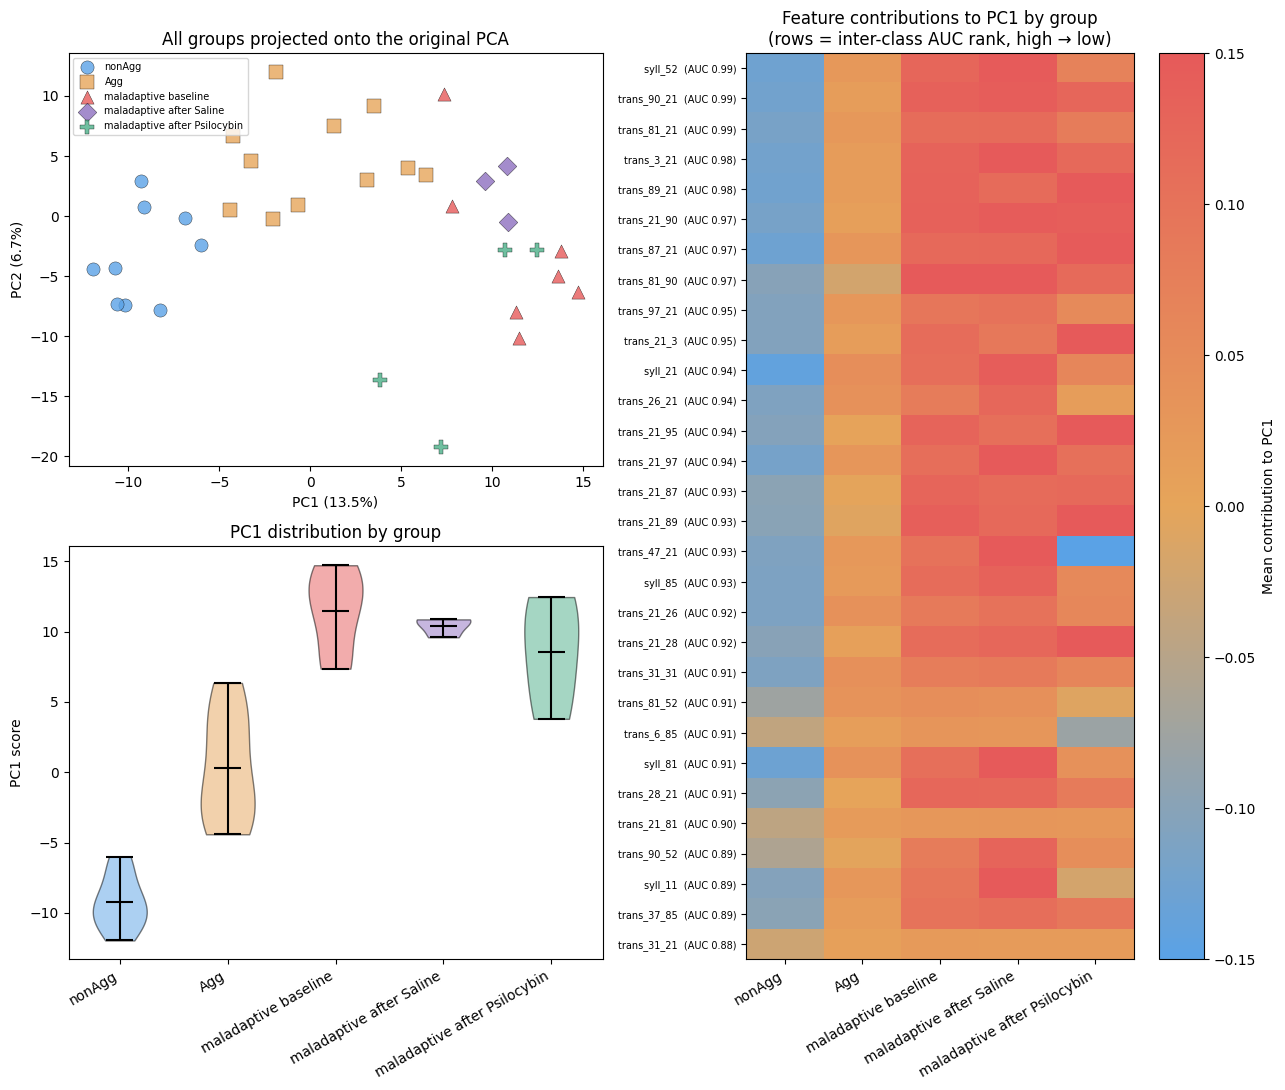

In [39]:
# =============================================================
# Project mouse AVERAGES of all groups onto the original PCA.
# Heatmap rows = the SAME AUC ranking already computed on the 3 baseline groups;
# saline & psilocybin are added only as extra columns.
# Requires from the model cell: pca, top_features, X_log, pc1_weights,
#                               top_features_ranked, auc_sep, pc_cmap
# =============================================================
# ---- EDIT colours / markers / order here (all groups) ----
plot_colors = {
    "nonAgg":                       "#5AA2E6",
    "Agg":                          "#E6A55A",
    "maladaptive baseline":         "#E65A5A",
    "maladaptive after Saline":     "#8E6FC0",
    "maladaptive after Psilocybin": "#4CAF88",
}
plot_markers = {
    "nonAgg": "o", "Agg": "s", "maladaptive baseline": "^",
    "maladaptive after Saline": "D", "maladaptive after Psilocybin": "P",
}
plot_order = ["nonAgg", "Agg", "maladaptive baseline",
              "maladaptive after Saline", "maladaptive after Psilocybin"]

# ---- project mouse averages (all groups) onto the fitted model ----
scaler = StandardScaler().fit(X_log[top_features])            # reproduces training transform
src = mouse_df.copy()
src["group_plot"] = src["group"]                             # keep all groups separate
Z = scaler.transform(np.log(
        src.reindex(columns=top_features).replace([np.inf, -np.inf], np.nan).fillna(0) + 1e-8))
P = pca.transform(Z)                                         # sign matches flipped axis
src["PC1"], src["PC2"] = P[:, 0], P[:, 1]

present = [g for g in plot_order if g in src["group_plot"].unique()]

# ---- per-group contributions, SAME rows/order/labels as before ----
contrib = pd.DataFrame(Z * pc1_weights.values, columns=top_features, index=src.index)
contrib["g"] = src["group_plot"].values
grp_contrib = contrib.groupby("g").mean().T
heat_all = grp_contrib.loc[top_features_ranked, present]                       # fixed AUC rank
heat_all.index = [f"{f}  (AUC {auc_sep[f]:.2f})" for f in top_features_ranked]  # same labels

CBAR_ABS = 0.15                      # <-- pick your max |contribution|; None = auto
m = CBAR_ABS if CBAR_ABS is not None else np.abs(heat_all.values).max()
norm = Normalize(vmin=-m, vmax=m)
sm = ScalarMappable(norm=norm, cmap=pc_cmap); sm.set_array([])

# ---- figure: scatter + violin (left column), heatmap (right, full height) ----
fig = plt.figure(figsize=(13, 11))
gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1])
ax_sc, ax_vi, ax_ht = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[:, 1])

# 1. PC1 vs PC2
for g in present:
    s = src[src["group_plot"] == g]
    ax_sc.scatter(s["PC1"], s["PC2"], label=g, color=plot_colors[g], marker=plot_markers[g],
                  s=90, alpha=0.8, edgecolor="black", linewidth=0.3)
ax_sc.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax_sc.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax_sc.set_title("All groups projected onto the original PCA"); ax_sc.legend(loc="best", fontsize=7)

# 2. PC1 distribution per group
vdata = [src.loc[src["group_plot"] == g, "PC1"].values for g in present]
vp = ax_vi.violinplot(vdata, showmeans=True, showmedians=False)
for body, g in zip(vp["bodies"], present):
    body.set_facecolor(plot_colors[g]); body.set_edgecolor("black"); body.set_alpha(0.5)
for key in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[key].set_color("black")
ax_vi.set_xticks(np.arange(1, len(present)+1)); ax_vi.set_xticklabels(present, rotation=30, ha="right")
ax_vi.set_ylabel("PC1 score"); ax_vi.set_title("PC1 distribution by group")

# 3. Feature contributions (same AUC rank, added groups)
ax_ht.imshow(heat_all, aspect="auto", cmap=pc_cmap, norm=norm)
ax_ht.set_xticks(np.arange(len(heat_all.columns))); ax_ht.set_xticklabels(heat_all.columns, rotation=30, ha="right")
ax_ht.set_yticks(np.arange(len(heat_all.index))); ax_ht.set_yticklabels(heat_all.index, fontsize=7)
ax_ht.set_title("Feature contributions to PC1 by group\n(rows = inter-class AUC rank, high → low)")
fig.colorbar(sm, ax=ax_ht).set_label("Mean contribution to PC1")

plt.tight_layout()
plt.show()

In [ ]:
import os
import re
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANNOT_DIR  = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\fig1_trainingSessions_annotationsNoemie_non_agg_mal")
BEHAVIOR   = "attackOfInt"
TARGET_FPS = 50.0
DO_PERM    = True

# Boolean column in resultsDataset that flags the MR (resident) sessions.
# Set to None to use every row.
MR_COLUMN  = "MR"

# --- syllable count from the FULL model, not the annotated subset ---
n_syll = max(int(np.asarray(results[k]["syllable"]).max()) for k in results) + 1

# --- (mouse, day) -> video key, straight from resultsDataset (MR only) ---
_meta = resultsDataset

_meta = _meta.copy()
_meta["mouse"] = _meta["mouse"].astype(str)
_meta["day"]   = _meta["day"].astype(int)
mr_lut = _meta.drop_duplicates(["mouse", "day"]).set_index(["mouse", "day"])["video"]

print(f"mr_lut: {len(mr_lut)} (mouse,day) entries after MR filter")
print(f"  sample mr_lut keys : {list(mr_lut.index[:6])}")


def parse_annot(path, behavior):
    fps, intervals, grab = None, [], False
    for ln in open(path, encoding="utf-8", errors="ignore").read().splitlines():
        s = ln.strip()
        if s.lower().startswith("annotation framerate"):
            fps = float(s.split(":")[1]); continue
        if s.startswith(">"):
            grab = (s[1:].strip() == behavior); continue
        if grab:
            p = s.split()
            if len(p) == 3 and p[0].lstrip("-").isdigit():
                intervals.append((int(p[0]), int(p[1])))
    return fps, intervals


# --- pool syllables + attack mask across annotated MR sessions ---
all_syll, all_att, matched = [], [], []
skips = Counter()
parsed_sample, files = [], sorted(ANNOT_DIR.rglob("*.annot"))

for path in files:
    m = re.search(r"m(?:ouse)?(\d+)_Day(\d+)", os.path.basename(path), re.IGNORECASE)
    if not m:
        skips["no_id_in_filename"] += 1
        continue
    mouse, day = str(m.group(1)), int(m.group(2))
    if len(parsed_sample) < 6:
        parsed_sample.append((mouse, day))
    if (mouse, day) not in mr_lut.index:
        skips["not_in_mr_lut"] += 1
        continue
    fps, iv = parse_annot(path, BEHAVIOR)
    if fps is None:
        skips["no_framerate"] += 1
        continue
    key = mr_lut.loc[(mouse, day)]
    if key not in results:
        skips["key_not_in_results"] += 1
        continue
    syll = np.asarray(results[key]["syllable"])
    step = max(1, int(round(fps / TARGET_FPS)))
    a = np.zeros(len(syll), bool)
    for start, stop in iv:
        lo, hi = (start - 1) // step, (stop - 1) // step
        a[max(0, lo):min(len(a), hi + 1)] = True
    all_syll.append(syll); all_att.append(a); matched.append(key)

print(f"\n.annot files found : {len(files)}")
print(f"matched sessions   : {len(matched)}")
print(f"skips              : {dict(skips)}")
print(f"  sample parsed keys : {parsed_sample}")

if not matched:
    raise RuntimeError(
        "No sessions matched -- nothing to concatenate.\n"
        "Compare 'sample mr_lut keys' with 'sample parsed keys' above:\n"
        "  * if the mouse strings differ (e.g. '1010819' vs 'mouse1010819'), fix the regex or the cast\n"
        "  * if days differ (2 vs 'Day02'), fix the day dtype\n"
        "  * if mr_lut is empty, MR_COLUMN filtered out every row (wrong column / all False)\n"
        "  * if skips are all 'no_id_in_filename', the filenames don't contain m<digits>_Day<digits>"
    )

S = np.concatenate(all_syll); A = np.concatenate(all_att); base = A.mean()
print(f"\nmatched {len(matched)} sessions | {len(S)} frames | n_syll={n_syll} | attack rate={base:.3f}")

# --- per-syllable enrichment + point-biserial correlation (over the FULL syllable space) ---
OH = np.stack([(S == k) for k in range(n_syll)], 1).astype(float)
O0 = OH - OH.mean(0); O0n = np.sqrt((O0 ** 2).sum(0))
corr_all = lambda a: (O0 * (a - a.mean())[:, None]).sum(0) / (O0n * np.sqrt(((a - a.mean()) ** 2).sum()) + 1e-12)
obs = corr_all(A.astype(float))

nfr = OH.sum(0).astype(int)
tab = pd.DataFrame({"syllable": range(n_syll), "n_frames": nfr,
                    "P_attack_given_syll": [A[S == k].mean() if (S == k).any() else np.nan for k in range(n_syll)]})
tab["log2_enrich"] = np.log2((tab["P_attack_given_syll"] + 1e-9) / (base + 1e-9))
tab["corr_r"] = np.where(nfr > 0, obs, np.nan)

if DO_PERM:
    rng = np.random.default_rng(0); n_perm = 500
    null = np.array([corr_all(np.concatenate([np.roll(a, int(rng.integers(1, len(a)))) for a in all_att]).astype(float))
                     for _ in range(n_perm)])
    tab["p_perm"] = np.where(nfr > 0, (np.sum(np.abs(null) >= np.abs(obs), 0) + 1) / (n_perm + 1), np.nan)

tab = tab.sort_values("corr_r", ascending=False)
print(tab.round(4).to_string(index=False))

t = tab.sort_values("syllable")
sig = (t["p_perm"] < 0.05) if DO_PERM else t["corr_r"].abs().gt(0)


mr_lut: 247 (mouse,day) entries after MR filter
  sample mr_lut keys : [('1010819', 2), ('1010819', 4), ('1010819', 5), ('1010819', 6), ('1010819', 7), ('1010819', 8)]

.annot files found : 45
matched sessions   : 42
skips              : {'no_id_in_filename': 1, 'not_in_mr_lut': 2}
  sample parsed keys : [('1010820', 2), ('1010820', 6), ('1010820', 12), ('1010823', 2), ('1010823', 6), ('1010823', 11)]

matched 42 sessions | 2634349 frames | n_syll=99 | attack rate=0.031
 syllable  n_frames  P_attack_given_syll  log2_enrich  corr_r  p_perm
       21     72450               0.6456       4.3699  0.5940  0.0020
       52      9468               0.7438       4.5741  0.2460  0.0020
       81      6630               0.6495       4.3785  0.1786  0.0020
       31      7603               0.4548       3.8645  0.1310  0.0020
       11     14688               0.2837       3.1836  0.1087  0.0020
       33      1828               0.4141       3.7292  0.0580  0.0020
       90     38074               0

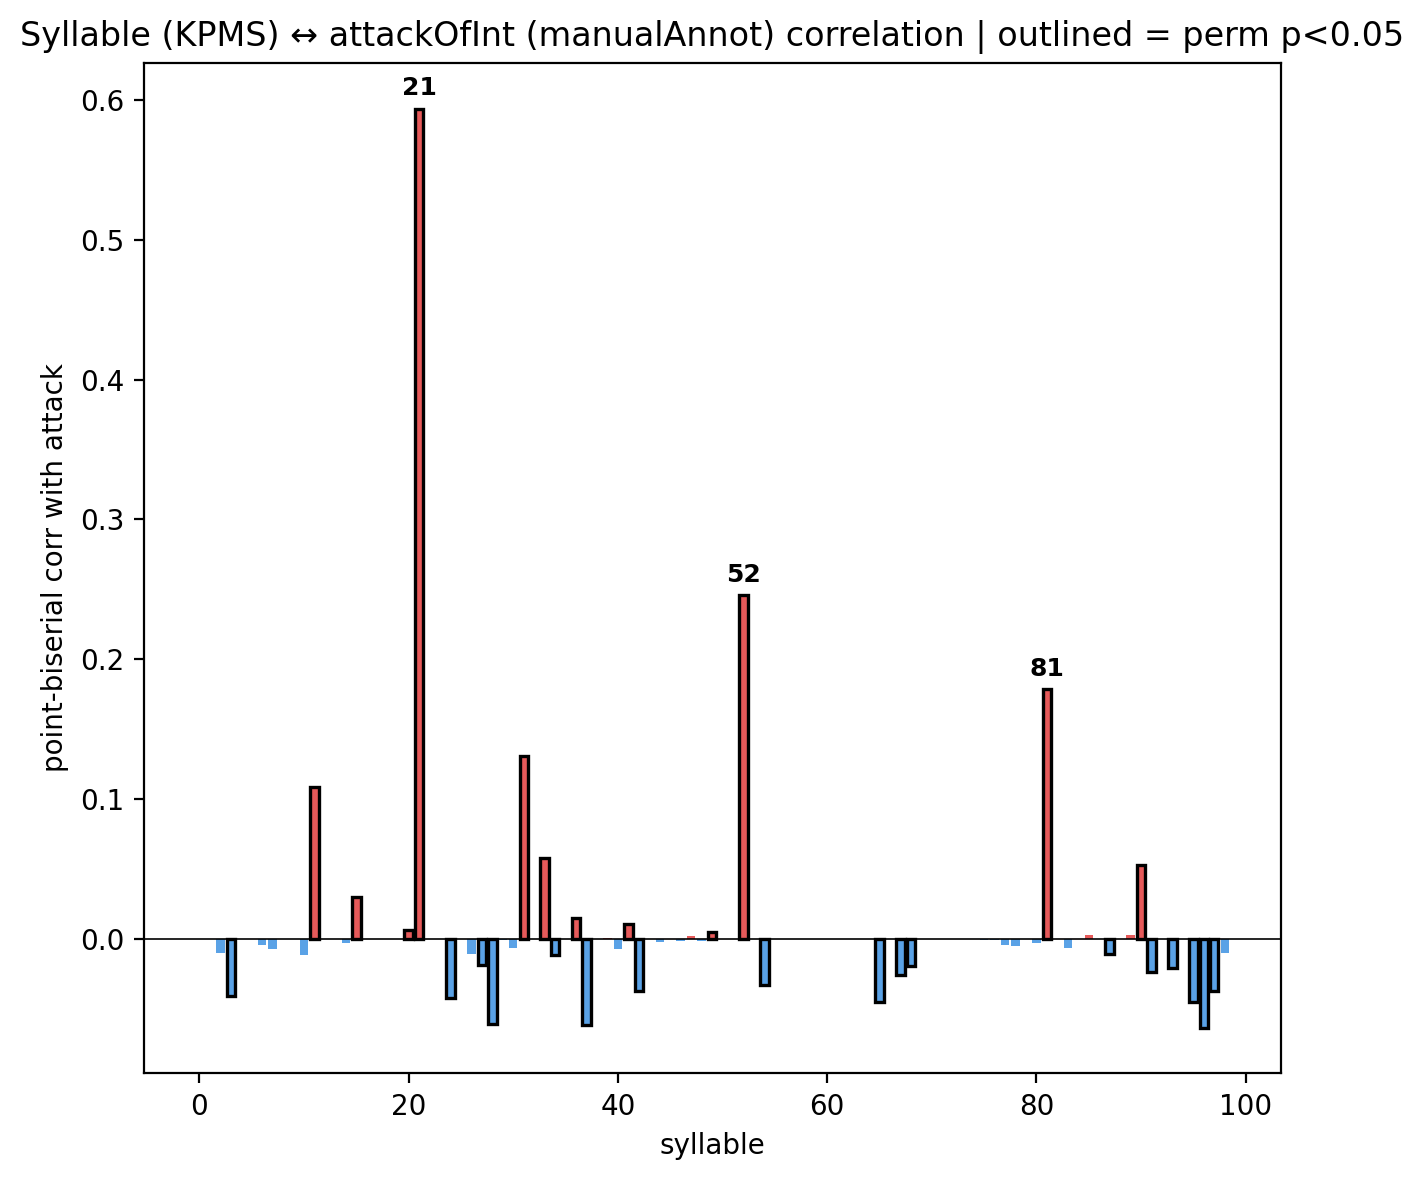

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6), dpi=200)
ax.bar(t["syllable"], t["corr_r"].fillna(0), color=np.where(t["corr_r"] > 0, "#E65A5A", "#5AA2E6"),
       edgecolor=np.where(sig.fillna(False), "black", "none"), linewidth=np.where(sig.fillna(False), 1.2, 0))
ax.axhline(0, color="black", lw=0.6)

# label the 3 syllables with the highest point-biserial correlation
top3 = t.nlargest(3, "corr_r")
for _, r in top3.iterrows():
    ax.annotate(str(int(r["syllable"])),
                (r["syllable"], r["corr_r"]),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("syllable"); ax.set_ylabel("point-biserial corr with attack")
ax.set_title(f"Syllable (KPMS) \u2194 {BEHAVIOR} (manualAnnot) correlation | outlined = perm p<0.05")
plt.tight_layout(); plt.show()

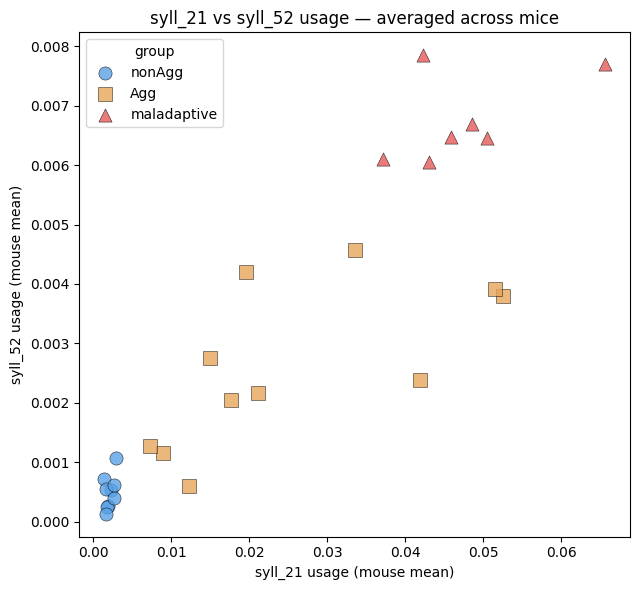

In [ ]:
# which two syllables to compare
SX, SY = 21, 52
col_x, col_y = f"syll_{SX}", f"syll_{SY}"

group_colors  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
group_order   = ["nonAgg", "Agg", "maladaptive"]

# baseline-only, then average each mouse's sessions -> one point per mouse
d = df[df["group"].isin(["nonAgg", "Agg", "maladaptive baseline"])].copy()
d["group_merged"] = d["group"].replace({"maladaptive baseline": "maladaptive"})
d = (d.groupby("mouse_group_id")
       .agg({col_x: "mean", col_y: "mean", "group_merged": "first"})
       .reset_index())

fig, ax = plt.subplots(figsize=(6.5, 6))
for g in group_order:
    sub = d[d["group_merged"] == g]
    ax.scatter(sub[col_x], sub[col_y],
               label=g, color=group_colors[g], marker=group_markers[g],
               s=90, alpha=0.8, edgecolor="black", linewidth=0.4)

ax.set_xlabel(f"{col_x} usage (mouse mean)")
ax.set_ylabel(f"{col_y} usage (mouse mean)")
ax.set_title(f"{col_x} vs {col_y} usage — averaged across mice")
ax.legend(title="group", loc="best", frameon=True)
plt.tight_layout()
plt.show()

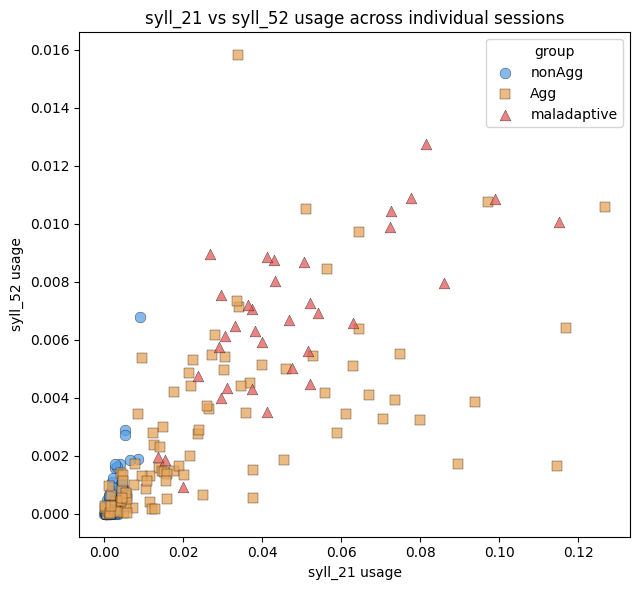

In [ ]:
# which two syllables to compare
SX, SY = 21, 52
col_x, col_y = f"syll_{SX}", f"syll_{SY}"

group_colors  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
group_order   = ["nonAgg", "Agg", "maladaptive"]

# individual sessions, baseline-only maladaptive (exclude after-Saline / after-Psilocybin)
d = df[df["group"].isin(["nonAgg", "Agg", "maladaptive baseline"])].copy()
d["group_merged"] = d["group"].replace({"maladaptive baseline": "maladaptive"})

fig, ax = plt.subplots(figsize=(6.5, 6))
for g in group_order:
    sub = d[d["group_merged"] == g]
    ax.scatter(sub[col_x], sub[col_y],
               label=g, color=group_colors[g], marker=group_markers[g],
               s=60, alpha=0.75, edgecolor="black", linewidth=0.3)

ax.set_xlabel(f"{col_x} usage")
ax.set_ylabel(f"{col_y} usage")
ax.set_title(f"{col_x} vs {col_y} usage across individual sessions")
ax.legend(title="group", loc="best", frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3d projection)

# three syllables -> x, y, z
SX, SY, SZ = 81, 21, 52
cx, cy, cz = f"syll_{SX}", f"syll_{SY}", f"syll_{SZ}"

SHOW_LABELS = False       # mouse-ID text at each point (clutters a rotating 3d view)
GIF_PATH    = "syll_3d_rotation.gif"
N_FRAMES    = 180         # 360 deg / 2 deg per frame
FPS         = 20

group_colors  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
group_order   = ["nonAgg", "Agg", "maladaptive"]

# one row per mouse, same exclusion/merge as the PCA cell
d = mouse_df.copy()
d = d[d["group"] != "maladaptive after Psilocybin"].copy()
d["group_merged"] = d["group"].replace({
    "maladaptive baseline": "maladaptive",
    "maladaptive after Saline": "maladaptive",
})

_id_candidates = ["mouse", "mouseID", "mouse_id", "id", "animal"]
id_col = next((c for c in _id_candidates if c in d.columns), None)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for g in group_order:
    sub = d[d["group_merged"] == g]
    ax.scatter(sub[cx], sub[cy], sub[cz],
               label=g, color=group_colors[g], marker=group_markers[g],
               s=70, alpha=0.85, edgecolor="black", linewidth=0.4, depthshade=True)
    if SHOW_LABELS:
        labels = sub[id_col].astype(str) if id_col else sub.index.astype(str)
        for x, y_, z_, lab in zip(sub[cx], sub[cy], sub[cz], labels):
            ax.text(x, y_, z_, lab, fontsize=5)

ax.set_xlabel(f"{cx} usage")
ax.set_ylabel(f"{cy} usage")
ax.set_zlabel(f"{cz} usage")
ax.set_title(f"{cx} / {cy} / {cz} usage across mice")
ax.legend(title="group", loc="upper left")


def update(angle):
    ax.view_init(elev=20, azim=angle)
    return fig,


anim = FuncAnimation(fig, update, frames=np.linspace(0, 360, N_FRAMES, endpoint=False),
                     interval=1000 / FPS, blit=False)
anim.save(GIF_PATH, writer=PillowWriter(fps=FPS), dpi=110)
plt.close(fig)
print(f"saved {GIF_PATH}  ({N_FRAMES} frames @ {FPS} fps)")

saved syll_3d_rotation.gif  (180 frames @ 20 fps)


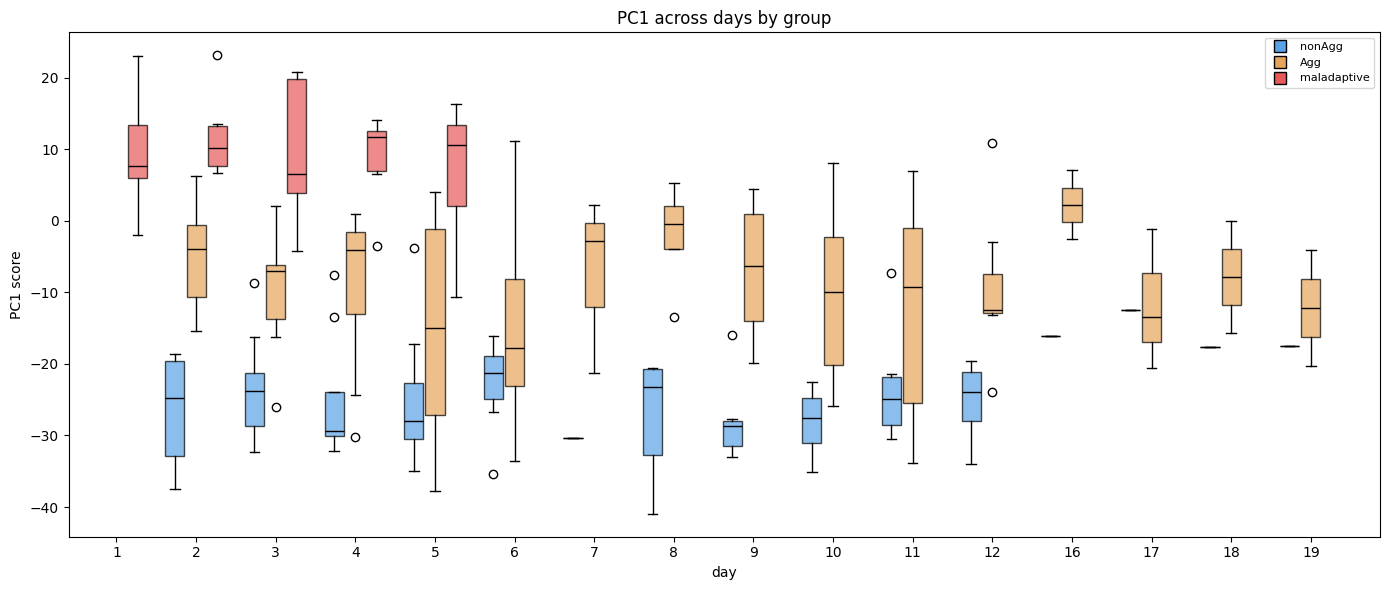

In [31]:
KEEP = ["nonAgg", "Agg", "maladaptive baseline"]

# session table, baseline-only
sess = df[df["group"].isin(KEEP)].copy()
sess["group_merged"] = sess["group"].replace({"maladaptive baseline": "maladaptive"})
sess["day_num"] = sess["day"].astype(str).str.extract(r"(\d+)").astype(float)

# PC1 from the full fitted model
scaler_full = StandardScaler().fit(X_log[top_features])
feat = sess.reindex(columns=top_features).replace([np.inf, -np.inf], np.nan).fillna(0)
sess["PC1"] = pca.transform(scaler_full.transform(np.log(feat + 1e-8)))[:, 0]

# grouped box plots: one box per (day, group), no lines
def grouped_box(ax, data, value, ylabel, title):
    days = sorted(data["day_num"].dropna().unique())
    n_g, width = len(group_order), 0.8 / len(group_order)
    for gi, g in enumerate(group_order):
        pos, vals = [], []
        for di, day in enumerate(days):
            v = data[(data["day_num"] == day) & (data["group_merged"] == g)][value].dropna().values
            if len(v):
                pos.append(di + (gi - (n_g - 1) / 2) * width); vals.append(v)
        if vals:
            bp = ax.boxplot(vals, positions=pos, widths=width * 0.9, patch_artist=True,
                            manage_ticks=False, medianprops=dict(color="black"))
            for box in bp["boxes"]:
                box.set_facecolor(group_colors[g]); box.set_alpha(0.7); box.set_edgecolor("black")
    ax.set_xticks(range(len(days))); ax.set_xticklabels([int(d) for d in days])
    ax.set_xlabel("day"); ax.set_ylabel(ylabel); ax.set_title(title)
    handles = [plt.Line2D([0], [0], marker="s", linestyle="none",
               markerfacecolor=group_colors[g], markeredgecolor="black", markersize=9, label=g)
               for g in group_order]
    ax.legend(handles=handles, loc="best", fontsize=8)

fig, ax = plt.subplots(figsize=(14, 6))
grouped_box(ax, sess, "PC1", "PC1 score", "PC1 across days by group")
plt.tight_layout(); plt.show()

syll_52 = 0.1113 * syll_21 + 0.00038   (r = 0.892, r^2 = 0.795)


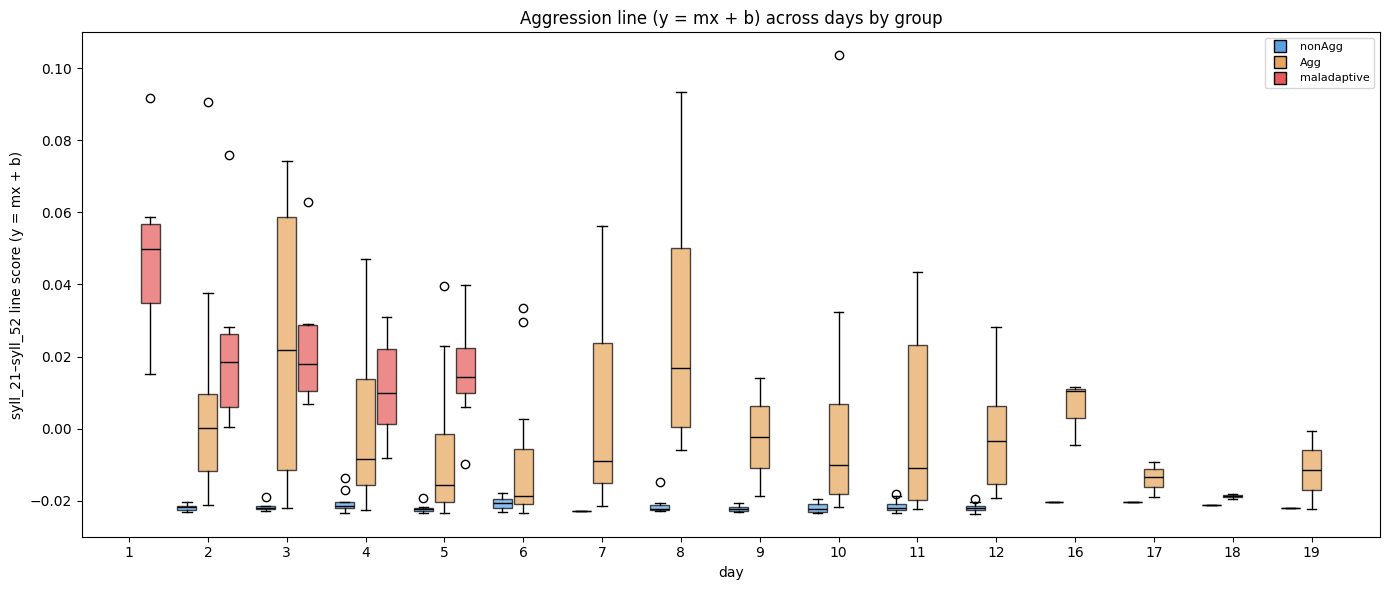

In [33]:
# aggression line: y = m*x + b on raw per-mouse baseline usage
AX_X, AX_Y = "syll_21", "syll_52"

base = mouse_df[mouse_df["group"].isin(KEEP)]
x, yv = base[AX_X].values, base[AX_Y].values
m, b = np.polyfit(x, yv, 1)                        # OLS in raw usage units
r = np.corrcoef(x, yv)[0, 1]
print(f"{AX_Y} = {m:.4f} * {AX_X} + {b:.5f}   (r = {r:.3f}, r^2 = {r**2:.3f})")

# per-session score = position along that line (raw usage)
u = np.array([1.0, m]) / np.hypot(1.0, m)
sess["agg_line"] = (sess[[AX_X, AX_Y]].values - [x.mean(), yv.mean()]) @ u

fig, ax = plt.subplots(figsize=(14, 6))
grouped_box(ax, sess, "agg_line", f"{AX_X}\u2013{AX_Y} line score (y = mx + b)",
            "Aggression line (y = mx + b) across days by group")
plt.tight_layout(); plt.show()

variance selection | permutations = 1000
silhouette (2D PCA) : real = +0.440 | null = -0.074 +/- 0.026 | z = +19.9 | p = 0.0010
PC1 ANOVA F         : real = 119.60 | null = 1.10 +/- 1.24 | z = +95.8 | p = 0.0010
  PC1 mean [     nonAgg] = +10.37
  PC1 mean [        Agg] = +1.66
  PC1 mean [maladaptive] = -11.17


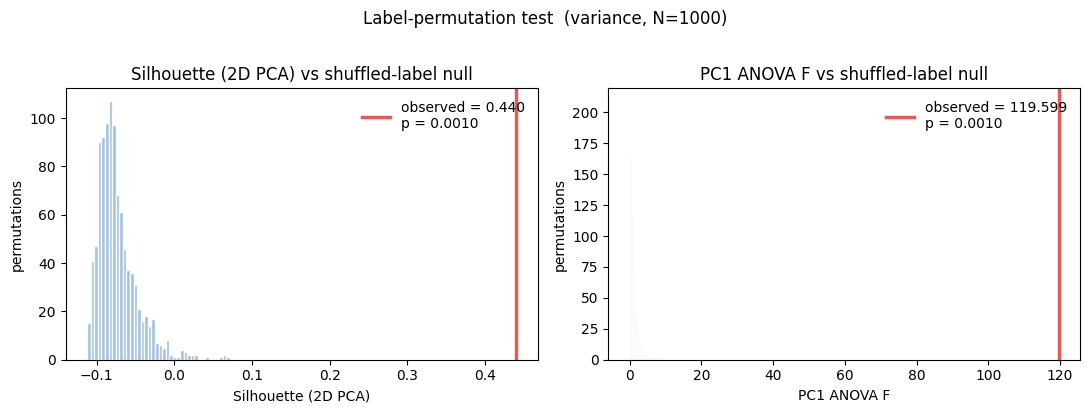

In [ ]:
# =============================================================
# Silhouette + label-permutation test (variance selection)
# Run this AFTER the feature-selection / PCA cell (reuses PC1/PC2 from it).
# Variance selection is label-blind, so the PCA embedding is fixed and we
# only re-score under shuffled labels -- the correct, efficient null.
# =============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway

N_PERM = 1000        # number of label shuffles
PERM_SEED = 0        # reproducibility

rng = np.random.default_rng(PERM_SEED)

# fixed embedding + integer labels, aligned to plot_df rows
emb = plot_df[["PC1", "PC2"]].values
labels_real = LabelEncoder().fit_transform(plot_df["group_merged"].values)


def pc1_F(embedding, y_vec):
    """One-way ANOVA F on PC1 across groups -- tests the PC1 spread directly."""
    groups = [embedding[y_vec == g, 0] for g in np.unique(y_vec)]
    return f_oneway(*groups).statistic


# ---- observed statistics ----
sil_real = silhouette_score(emb, labels_real)   # higher = better separated
F_real   = pc1_F(emb, labels_real)

# ---- null distribution under shuffled labels (embedding stays fixed) ----
null_sil = np.empty(N_PERM)
null_F   = np.empty(N_PERM)
for i in range(N_PERM):
    yp = rng.permutation(labels_real)
    null_sil[i] = silhouette_score(emb, yp)
    null_F[i]   = pc1_F(emb, yp)

# permutation p-values (one-sided, +1 correction) and z vs the null
p_sil = (1 + np.sum(null_sil >= sil_real)) / (1 + N_PERM)
p_F   = (1 + np.sum(null_F   >= F_real))   / (1 + N_PERM)
z_sil = (sil_real - null_sil.mean()) / (null_sil.std() + 1e-12)
z_F   = (F_real   - null_F.mean())   / (null_F.std()   + 1e-12)

print(f"variance selection | permutations = {N_PERM}")
print(f"silhouette (2D PCA) : real = {sil_real:+.3f} | null = {null_sil.mean():+.3f} +/- {null_sil.std():.3f} "
      f"| z = {z_sil:+.1f} | p = {p_sil:.4f}")
print(f"PC1 ANOVA F         : real = {F_real:.2f} | null = {null_F.mean():.2f} +/- {null_F.std():.2f} "
      f"| z = {z_F:+.1f} | p = {p_F:.4f}")
for g in group_order:
    m = plot_df.loc[plot_df["group_merged"] == g, "PC1"].mean()
    print(f"  PC1 mean [{g:>11}] = {m:+.2f}")

# ---- figure: observed vs null ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, null, real, p, name in [
    (axes[0], null_sil, sil_real, p_sil, "Silhouette (2D PCA)"),
    (axes[1], null_F,   F_real,   p_F,   "PC1 ANOVA F"),
]:
    ax.hist(null, bins=40, color="#9bbcd6", edgecolor="white", alpha=0.9)
    ax.axvline(real, color="#E65A5A", lw=2.5, label=f"observed = {real:.3f}\np = {p:.4f}")
    ax.set_xlabel(name)
    ax.set_ylabel("permutations")
    ax.set_title(f"{name} vs shuffled-label null")
    ax.legend(loc="upper right", frameon=False)

fig.suptitle(f"Label-permutation test  (variance, N={N_PERM})", y=1.02)
plt.tight_layout()
plt.savefig("silhouette_permutation.png", dpi=150, bbox_inches="tight")
plt.show()